In [2]:
import pandas as pd
import numpy as np
import nibabel as nib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

(-0.5, 255.5, 0.5, -0.5)

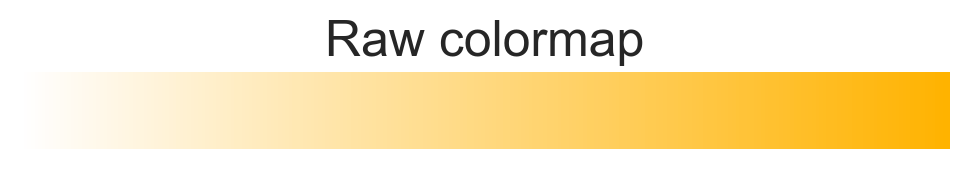

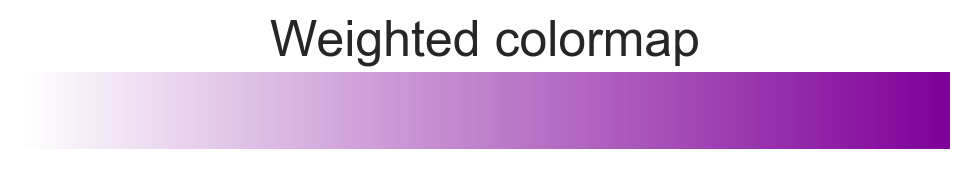

In [3]:
# ── Global visualisation configuration ──────────────────────────────────────

# 1.  General Matplotlib defaults
# ── Global visualisation configuration ──────────────────────────────────────
import matplotlib as mpl
import seaborn as sns

mpl.rcParams.update(
    {
        # ── Canvas size & resolution ───────────────────────────────────────────
        # Default figure size: 12×8 inches  →  4800×3200 px when exported at 400 dpi
        "figure.figsize": (12, 8),
        "figure.dpi": 200,  # crisp in-notebook / retina preview
        "savefig.dpi": 400,  # print-quality PNG/PDF
        # ── Fonts ──────────────────────────────────────────────────────────────
        "font.family": "sans-serif",
        "font.sans-serif": ["Roboto", "DejaVu Sans", "Arial"],
        "axes.titlesize": 24,
        # "axes.titleweight": "bold",
        "axes.labelsize": 24,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 20,
        # ── Axis & spine aesthetics ────────────────────────────────────────────
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": True,
        "axes.spines.bottom": True,
        "axes.linewidth": 1,
        "axes.grid": True,
        "grid.color": "#E6E6E6",
        "grid.linewidth": 0.4,
        "grid.alpha": 0.8,
        # ── Colour cycle (colour-blind-safe) ───────────────────────────────────
        "axes.prop_cycle": mpl.cycler(color=sns.color_palette("Set2")),
        # ── Figure background ─────────────────────────────────────────────────
        "figure.facecolor": "white",
    }
)

# Seaborn theme inherits the rcParams above
sns.set_theme(context="talk", style="whitegrid", palette="Set2")


# 2.  Seaborn theme (inherits Matplotlib rcParams)
sns.set_theme(
    context="talk",  # slightly larger fonts for presentations / papers
    style="whitegrid",  # grid only on y-axis (good for histograms)
    palette="Set2",  # matches the rcParams colour cycle
)


# 3.  Helper function for consistent figure export
def savefig_nice(fig, filename, *, tight=True, dpi=300, **savefig_kwargs):
    """Save figure with tight layout and correct DPI."""
    if tight:
        fig.tight_layout()
    fig.savefig(filename, dpi=dpi, bbox_inches="tight", transparent=True, **savefig_kwargs)


# 4.  Colour constants for this project (optional convenience)
# COL_RAW = "#1f77b4"  # e.g. unweighted sample
COL_RAW = "#ffb300"
# COL_WEIGHTED = "#d62728"  # weighted sample
COL_WEIGHTED = "#7F0099CE"  # weighted sample
COL_REF = "0.25"  # census reference (neutral grey)
COL_CENSUS = "#A5A5A5"

# generate colormaps from white to colour
COL_WHITE = "white"
COL_RAW_RGB = mpl.colors.to_rgb(COL_RAW)
COL_WEIGHTED_RGB = mpl.colors.to_rgb(COL_WEIGHTED)
CMAP_RAW = mpl.colors.LinearSegmentedColormap.from_list("raw", [COL_WHITE, COL_RAW_RGB], N=256)
CMAP_WEIGHTED = mpl.colors.LinearSegmentedColormap.from_list(
    "weighted", [COL_WHITE, COL_WEIGHTED_RGB], N=256
)
# visualize the colormaps
# if __name__ == "__main__":
fig, ax = plt.subplots(figsize=(6, 0.5))
ax.imshow(np.linspace(0, 1, 256)[None, :], aspect="auto", cmap=CMAP_RAW)
ax.set_title("Raw colormap")
ax.axis("off")
# savefig_nice(fig, "colormap_raw.png")

fig, ax = plt.subplots(figsize=(6, 0.5))
ax.imshow(np.linspace(0, 1, 256)[None, :], aspect="auto", cmap=CMAP_WEIGHTED)
ax.set_title("Weighted colormap")
ax.axis("off")
# savefig_nice(fig, "colormap_weighted.png")

In [4]:
ATLAS = "schaefer2018tian2020_400_7"
region_col = "index"
# Load important files
DATA_DIR = Path("/home/galkepler/Projects/neuroaging/data")

# Output directory for figures
OUTPUT_DIR = Path("/home/galkepler/Projects/neuroaging/figures/fig4")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load the data
parcels = pd.read_csv(DATA_DIR / "external" / "atlases" / ATLAS / "parcels.csv", index_col=0)
nifti = DATA_DIR / "external" / "atlases" / ATLAS / "atlas.nii.gz"
nifti_matlab = DATA_DIR / "external" / "atlases" / ATLAS / "atlas_matlab.nii"

In [ ]:
metrics = ["gm_vol", "wm_vol", "csf_vol", "adc", "fa", "ad", "rd"]
distribution_metric = "qfmean"

bad_subjects = ["IN120120"]

# Load the data
data = {}
for metric in metrics:
    data[metric] = pd.read_csv(DATA_DIR / "processed" / f"{metric}.csv", index_col=0).reset_index(
        drop=True
    )
    # drop problematic subjects
    data[metric] = data[metric][~data[metric]["subject_code"].isin(bad_subjects)]
    data[metric]["sex"] = data[metric]["sex"].map({"M": 0, "F": 1})


# data["age_squared"] = data["age_at_scan"] ** 2

In [ ]:
metric_cols = {metric: "volume" if "vol" in metric else distribution_metric for metric in metrics}

for m, df in data.items():
    df = df.rename(columns={metric_cols[m]: "value"})
    data[m] = df

In [ ]:
israel_population = pd.read_csv(DATA_DIR / "processed" / "israel_population.csv")

In [ ]:
import numpy as np
import pandas as pd


# ─────────────────────────────────────────────────────────────────────────────
def compute_poststrat_weights(
    sample_df: pd.DataFrame,
    pop_df: pd.DataFrame,
    *,
    age_col: str = "age_at_scan",
    start_col: str = "range_start",
    end_col: str = "range_end",
    pop_total_col: str = "total",
    cap: float | None = None,
    return_bin_table: bool = False,
):
    """
    Post-stratification weights so that the age distribution of *sample_df*
    matches an external population distribution supplied in *pop_df*.

    Parameters
    ----------
    sample_df : DataFrame with an ``age_col`` column (years; int or float).
    pop_df    : DataFrame with columns
                    [start_col, end_col, pop_total_col].
                * Values in ``pop_total_col`` can be counts **or** percentages
                  (they are internally re-scaled to proportions).
                * The row order doesn’t matter; they will be sorted.
    cap       : Optional float.  If provided, weights are truncated at
                ``cap × mean(weight)`` and then re-scaled so mean(weight)=1.
    return_bin_table : If True, also return a DataFrame summarising
                       n_sample, n_pop, and weight_factor for every bin.

    Returns
    -------
    weights   : 1-D numpy array aligned with ``sample_df.index``.
    bin_table : (optional) tidy per-bin summary (see above).
    """

    # 1 ── tidy & validate the population table --------------------------------
    pop = (
        pop_df[[start_col, end_col, pop_total_col]]
        .dropna()
        .astype({start_col: int, end_col: int, pop_total_col: float})
        .sort_values(start_col)  # your CSV is descending; fix that
        .reset_index(drop=True)
    )

    if (pop[end_col] <= pop[start_col]).any():
        raise ValueError("Each range_end must exceed range_start.")

    if (pop[start_col].iloc[1:].values < pop[end_col].iloc[:-1].values).any():
        overlap = pop.iloc[
            np.where(pop[start_col].iloc[1:].values < pop[end_col].iloc[:-1].values)[0] + 1
        ][[start_col, end_col]]
        raise ValueError(
            "Age bins overlap (rows shown below) — "
            "merge / correct them before weighting:\n"
            f"{overlap}"
        )

    # 2 ── build right-inclusive bin edges  (···| s_i  …  e_i | s_{i+1} …) ----
    edges = pop[start_col].tolist() + [pop[end_col].iloc[-1]]

    # 3 ── assign every participant to a bin -----------------------------------
    s_bins = pd.cut(
        sample_df[age_col],
        bins=edges,
        right=True,
        include_lowest=True,
        labels=pop.index,  # categorical labels 0,1,…
    )

    # 4 ── compute *sample* and *population* proportions per bin --------------
    n_sample = s_bins.value_counts(sort=False).sort_index()
    prop_sample = n_sample / n_sample.sum()

    prop_pop = pop[pop_total_col] / pop[pop_total_col].sum()

    # 5 ── weight factor = pop_prop / sample_prop ------------------------------
    weight_factor = prop_pop / prop_sample.replace(0, np.nan)  # avoid /0 → NaN

    # 6 ── map factor back to each row ----------------------------------------
    w = s_bins.map(weight_factor).astype(float).to_numpy()
    w = np.where(np.isnan(w), 0.0, w)  # rows that fell outside bins → 0

    # 7 ── optional weight truncation (winsorisation) --------------------------
    if cap is not None and cap > 0:
        mean_pos = w[w > 0].mean()
        w = np.clip(w, 0, cap * mean_pos)

    # 8 ── re-scale so mean(weight > 0) == 1 -----------------------------------
    positive = w > 0
    w[positive] = w[positive] / w[positive].mean()

    # 9 ── return --------------------------------------------------------------
    if return_bin_table:
        bin_tbl = pd.DataFrame(
            {
                "n_sample": n_sample,
                "n_pop": prop_pop * n_sample.sum(),  # rescaled to sample size
                "prop_sample": prop_sample,
                "prop_pop": prop_pop,
                "weight_factor": weight_factor,
            }
        )
        return w, bin_tbl

    return w

In [ ]:
# assign weights
for metric in metrics:
    data[metric]["weight"], _ = compute_poststrat_weights(
        data[metric],
        israel_population,
        age_col="age_at_scan",
        cap=None,  # try None first; if still spiky, use 4 or 5
        return_bin_table=True,
    )
    data[metric]["subject_code"] = data[metric]["subject_code"].astype(str).str.zfill(4)

In [ ]:
# df_long = data["adc"].copy()
# df_long[df_long["subject_code"] == 447]["subject_code"]

In [ ]:
import pandas as pd
from functools import reduce


def long_to_wide(
    long_df,
    *,
    index="subject_code",
    columns=region_col,
    values="value",
):
    """Pivot a long metric table → wide DataFrame (subjects × regions)."""
    wide = long_df.pivot_table(index=index, columns=columns, values=values, aggfunc="first")
    # Optional: drop regions with >20 % missing values
    thresh = int(0.8 * len(wide))
    wide = wide.dropna(axis=1, thresh=thresh)
    # Optional: drop subejcts with >20 % missing values
    thresh = int(0.8 * len(parcels))
    wide = wide.dropna(axis=0, thresh=thresh)
    return wide


def prep_metric_matrices(metric_dict, *, index="subject_code"):
    """
    Parameters
    ----------
    metric_dict : {metric_name: long_df}
        Each DataFrame must include `subject_id`, `region`, `value`,
        `age_at_scan`, and any covariates you want.
    Returns
    -------
    X_dict : {metric_name: ndarray}
             Wide feature matrices aligned on the *intersection* of subjects.
    y, w, cov_df : Series / ndarray
             Age, weights, and any extra covariates for the same subjects.
    """
    # 1.  Convert every long → wide
    wide_dict = {m: long_to_wide(df) for m, df in metric_dict.items()}

    # 2.  Intersect subject index across all metrics
    common_subs = reduce(pd.Index.intersection, [w.index for w in wide_dict.values()])

    # 3.  Slice & order every matrix
    for m in wide_dict:
        wide_dict[m] = wide_dict[m].loc[common_subs]

    # 4.  Pull y, w, covariates from *any* of the long dfs (they all duplicate)
    ref_long = next(iter(metric_dict.values()))
    ref_meta = (
        ref_long.drop_duplicates(subset=index)  # one row per subject
        .set_index(index)
        .loc[common_subs]
    )
    y = ref_meta["age_at_scan"]
    w = ref_meta.get("weight", pd.Series(1.0, index=common_subs))
    cov = ref_meta[ref_meta.columns.difference(["age_at_scan", "weight"])]

    # 5.  Convert features to numpy (sklearn ready)
    X_dict = {m: wide.to_numpy() for m, wide in wide_dict.items()}
    return X_dict, y.to_numpy(), w.to_numpy(), cov

In [ ]:
# -------------------------------------------------------
# Build (X, y, w, cov) once, re-use in every metric loop
# -------------------------------------------------------
X_dict, y, w, cov = prep_metric_matrices(data)
# y_mean = y.mean()
# y = y - y_mean  # center the target variable
# Example list of covariates you want to *keep* (z-scored later if needed)
cov_names = {
    m: ["sex"] if "vol" not in m else ["sex", "tiv"] for m in metrics
}  # e.g. ["sex", "tiv"]

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Union
from sklearn.base import BaseEstimator
from sklearn.model_selection import BaseCrossValidator
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures


def cross_val_predict_with_posthoc(
    model: BaseEstimator,
    X: Union[np.ndarray, pd.DataFrame],
    y: np.ndarray,
    w: np.ndarray,
    cv: BaseCrossValidator,
    *,
    use_weights: bool = True,
    post_hoc_degree: int = 1,
) -> np.ndarray:
    """
    Cross-validated predictions with OPTIONAL linear / polynomial
    post-hoc bias-correction (fit on training residuals only).

    Parameters
    ----------
    model            : any scikit-learn regressor or pipeline
    X                : shape (n_samples, n_features)
    y                : shape (n_samples,) – chronological age
    w                : sample weights, shape (n_samples,)
    cv               : cross-validator providing (train_idx, test_idx)
    use_weights      : if False, sample weights are ignored
    post_hoc_degree  : 0 ⇒ no correction; 1 ⇒ linear; 2 ⇒ quadratic …

    Returns
    -------
    y_pred_corr      : bias-corrected out-of-fold predictions
    """

    # ensure array-like indexing works
    X_arr = X.values if isinstance(X, pd.DataFrame) else X
    y = np.asarray(y)
    w = np.asarray(w)

    y_oof = np.full_like(y, np.nan, dtype=float)

    original_residuals = np.full_like(y, np.nan, dtype=float)
    corrected_residuals = np.full_like(y, np.nan, dtype=float)

    for all_train_idx, test_idx in cv.split(X_arr, y):
        train_idx, val_idx = train_test_split(all_train_idx, test_size=0.2, random_state=42)
        X_tr, X_te, X_val = X_arr[train_idx], X_arr[test_idx], X_arr[val_idx]
        y_tr, y_te, y_val = y[train_idx], y[test_idx], y[val_idx]
        w_tr = w[train_idx]
        w_val = w[val_idx]

        # ---------------- fit base model -----------------------------
        fit_kwargs = {"estimator__sample_weight": w_tr} if use_weights else {}
        model.fit(X_tr, y_tr, **fit_kwargs)

        # ---------------- predict on test fold -----------------------
        y_pred_te = model.predict(X_te)
        y_pred_val = model.predict(X_val)
        y_pred_tr = model.predict(X_tr)
        # ---------------- optional post-hoc bias ---------------------
        if post_hoc_degree > 0:
            orig_resid_te = y_te - y_pred_te
            lin = LinearRegression()
            if post_hoc_degree > 1:
                poly = PolynomialFeatures(degree=post_hoc_degree)
                resid_model = Pipeline([("poly", poly), ("lin", lin)])
            else:
                resid_model = Pipeline([("lin", lin)])
            fit_kwargs = {"lin__sample_weight": w_val} if use_weights else {}
            resid_model.fit(y_val.reshape(-1, 1), y_val - y_pred_val)
            # a, b = lin.intercept_, lin.coef_[0]
            # y_pred_te = (y_pred_te - a) / b
            y_pred_te = y_pred_te + resid_model.predict(y_pred_te.reshape(-1, 1))
            original_residuals[test_idx] = orig_resid_te
            corrected_residuals[test_idx] = y_te - y_pred_te
            # resid_tr = y_tr - model.predict(X_tr)
            # coeffs = np.polyfit(y_pred_tr, resid_tr, post_hoc_degree)
            # bias_fn = np.poly1d(coeffs)
            # orig_resid_te = y_te - y_pred_te
            # te_bias = bias_fn(y_pred_te)
            # y_pred_te = y_pred_te + te_bias
            # original_residuals[test_idx] = orig_resid_te
            # corrected_residuals[test_idx] = y_te - y_pred_te

        y_oof[test_idx] = y_pred_te

    return y_oof, original_residuals, corrected_residuals

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Union
from sklearn.base import BaseEstimator
from sklearn.model_selection import BaseCrossValidator
import statsmodels.api as sm  # Not strictly needed here, LinearRegression is sufficient
from statsmodels.formula.api import ols  # Not strictly needed here
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline  # Make sure this is imported!


def cross_val_predict_with_de_lange_beheshti(
    model: BaseEstimator,
    X: Union[np.ndarray, pd.DataFrame],
    y: np.ndarray,
    w: np.ndarray,
    cv: BaseCrossValidator,
    *,
    use_weights: bool = True,
    # post_hoc_degree is not directly applicable in this exact formulation
    # but could be adapted if you regress y_actual on poly(y_predicted)
) -> np.ndarray:
    """
    Cross-validated predictions with post-hoc de Lange/Beheshti-style
    linear bias-correction (fit on training residuals only).

    Parameters
    ----------
    model            : any scikit-learn regressor or pipeline
    X                : shape (n_samples, n_features)
    y                : shape (n_samples,) – chronological age
    w                : sample weights, shape (n_samples,)
    cv               : cross-validator providing (train_idx, test_idx)
    use_weights      : if False, sample weights are ignored

    Returns
    -------
    y_pred_corr      : bias-corrected out-of-fold predictions
    original_residuals : uncorrected residuals (actual - predicted)
    corrected_residuals : corrected residuals (actual - corrected_predicted)
    """

    # ensure array-like indexing works
    X_arr = X.values if isinstance(X, pd.DataFrame) else X
    y = np.asarray(y)
    w = np.asarray(w)

    y_oof = np.full_like(y, np.nan, dtype=float)
    original_residuals = np.full_like(y, np.nan, dtype=float)
    corrected_residuals = np.full_like(y, np.nan, dtype=float)

    for all_train_idx, test_idx in cv.split(X_arr, y):
        # Nested split for training base model and fitting bias correction
        train_idx, val_idx = train_test_split(all_train_idx, test_size=0.2, random_state=42)
        X_tr, X_te, X_val = X_arr[train_idx], X_arr[test_idx], X_arr[val_idx]
        y_tr, y_te, y_val = y[train_idx], y[test_idx], y[val_idx]
        w_tr = w[train_idx]
        w_val = w[val_idx]

        # ---------------- fit base model -----------------------------
        fit_kwargs = {"sample_weight": w_tr} if use_weights else {}
        # If 'model' is a pipeline, use 'estimator__sample_weight' or appropriate step name
        if isinstance(model, Pipeline):
            fit_kwargs = {model.steps[-1][0] + "__sample_weight": w_tr} if use_weights else {}
        model.fit(X_tr, y_tr, **fit_kwargs)

        # ---------------- predict on test and validation folds -----------------------
        y_pred_te_original = model.predict(X_te)
        y_pred_val = model.predict(X_val)

        # ---------------- Post-hoc de Lange/Beheshti bias correction ---------------
        # Fit a linear model: y_actual = a + b * y_predicted
        bias_corrector = LinearRegression()
        # Reshape y_pred_val for single feature input to LinearRegression
        fit_kwargs_bias = {"sample_weight": w_val} if use_weights else {}
        bias_corrector.fit(y_pred_val.reshape(-1, 1), y_val, **fit_kwargs_bias)

        alpha = bias_corrector.intercept_
        beta = bias_corrector.coef_[0]

        # Apply correction: y_corrected = (y_predicted - alpha) / beta
        # This transforms the predicted age to follow the identity line with actual age
        # on average across the age range.
        if beta != 0:  # Avoid division by zero
            y_pred_te_corrected = (y_pred_te_original - alpha) / beta
        else:  # Fallback if beta is zero (unlikely with real data but for robustness)
            y_pred_te_corrected = y_pred_te_original  # No effective correction

        # Store results
        y_oof[test_idx] = y_pred_te_corrected
        original_residuals[test_idx] = y_te - y_pred_te_original
        corrected_residuals[test_idx] = y_te - y_pred_te_corrected

    return y_oof, original_residuals, corrected_residuals

In [ ]:
import numpy as np
import pandas as pd
from typing import Union
from sklearn.base import BaseEstimator
from sklearn.model_selection import BaseCrossValidator
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline  # Make sure this is imported for PolynomialFeatures usage


def cross_val_predict_with_bias_correction(
    model: BaseEstimator,
    X: Union[np.ndarray, pd.DataFrame],
    y_chronological: np.ndarray,  # y in paper's notation
    w: np.ndarray,
    cv: BaseCrossValidator,
    *,
    use_weights: bool = True,
    post_hoc_degree: int = 0,  # 0 = no correction, 1 = linear de Lange/Beheshti, >1 = polynomial residual correction
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Cross-validated predictions with optional post-hoc bias-correction.

    Parameters
    ----------
    model            : any scikit-learn regressor or pipeline
    X                : shape (n_samples, n_features)
    y_chronological  : shape (n_samples,) – chronological age (y in paper's notation)
    w                : sample weights, shape (n_samples,)
    cv               : cross-validator providing (train_idx, test_idx)
    use_weights      : if False, sample weights are ignored
    post_hoc_degree  : int
                       0 = no bias correction applied.
                       1 = linear de Lange et al. / Beheshti-style correction (fit x=a*y+b, correct (x-b)/a).
                       >1 = polynomial residual correction (fit residuals as poly of predicted_age, add to prediction).

    Returns
    -------
    y_pred_corr      : bias-corrected out-of-fold predictions
    original_residuals : uncorrected residuals (chronological_age - original_predicted_age)
    corrected_residuals : corrected residuals (chronological_age - corrected_predicted_age)
    """

    # Ensure array-like indexing works
    X_arr = X.values if isinstance(X, pd.DataFrame) else X
    y_chronological = np.asarray(y_chronological)
    w = np.asarray(w)

    y_oof_corrected = np.full_like(y_chronological, np.nan, dtype=float)
    original_residuals = np.full_like(y_chronological, np.nan, dtype=float)
    corrected_residuals = np.full_like(y_chronological, np.nan, dtype=float)

    for all_train_idx, test_idx in cv.split(X_arr, y_chronological):
        # Nested split for training base model and fitting bias correction model
        train_idx, val_idx = train_test_split(all_train_idx, test_size=0.2, random_state=42)

        X_tr, X_te, X_val = X_arr[train_idx], X_arr[test_idx], X_arr[val_idx]
        y_tr, y_te, y_val = (
            y_chronological[train_idx],
            y_chronological[test_idx],
            y_chronological[val_idx],
        )
        w_tr = w[train_idx]
        w_val = w[val_idx]

        # ---------------- Fit base model -----------------------------
        fit_kwargs = {"sample_weight": w_tr} if use_weights else {}
        if isinstance(model, Pipeline):
            fit_kwargs = {model.steps[-1][0] + "__sample_weight": w_tr} if use_weights else {}
        model.fit(X_tr, y_tr, **fit_kwargs)

        # ---------------- Predict on test and validation folds -----------------------
        y_pred_te_original = model.predict(X_te)
        y_pred_val = model.predict(X_val)

        # ---------------- Post-hoc bias correction (conditional on post_hoc_degree) ---------------
        if post_hoc_degree > 0:
            if post_hoc_degree == 1:
                # --- Linear de Lange et al. / Beheshti-style correction ---
                # Fit a linear model: x = a*y + b
                # Where x is predicted_age (y_pred_val) and y is chronological_age (y_val)
                bias_corrector = LinearRegression()
                # fit_kwargs_bias = {"sample_weight": w_val} if use_weights else {}
                fit_kwargs_bias = {}
                # Fit: y_pred_val (dependent) on y_val (independent)
                bias_corrector.fit(y_val.reshape(-1, 1), y_pred_val, **fit_kwargs_bias)

                a_coeff = bias_corrector.coef_[0]  # This is 'a' from x = a*y + b
                b_intercept = bias_corrector.intercept_  # This is 'b' from x = a*y + b

                # Apply correction: x_corrected = (x - b) / a
                if a_coeff != 0:  # Avoid division by zero
                    y_pred_te_corrected = (y_pred_te_original - b_intercept) / a_coeff
                else:
                    y_pred_te_corrected = (
                        y_pred_te_original  # No effective correction if no linear relationship
                    )
            else:  # post_hoc_degree > 1
                # --- Polynomial Residual Correction (your original approach) ---
                # Fit residuals (y_val - y_pred_val) as a polynomial function of predicted_age (y_pred_val)
                poly = PolynomialFeatures(degree=post_hoc_degree)
                lin = LinearRegression()

                # Create a pipeline for the residual model: poly features of predicted age -> linear regression
                resid_model_pipeline = Pipeline([("poly", poly), ("lin", lin)])

                # Fit the residual model on validation data
                # Independent variable: y_pred_val (predicted age on validation set)
                # Dependent variable: y_val - y_pred_val (residuals on validation set)
                # fit_kwargs_resid_model = {"lin__sample_weight": w_val} if use_weights else {}
                fit_kwargs_resid_model = {}
                resid_model_pipeline.fit(
                    y_pred_val.reshape(-1, 1), y_val - y_pred_val, **fit_kwargs_resid_model
                )

                # Predict the bias component for the test set using its original predictions
                bias_component_te = resid_model_pipeline.predict(y_pred_te_original.reshape(-1, 1))

                # Add the predicted bias component to the original predictions
                y_pred_te_corrected = y_pred_te_original + bias_component_te
        else:  # post_hoc_degree == 0, no correction
            y_pred_te_corrected = y_pred_te_original

        # Store results
        y_oof_corrected[test_idx] = y_pred_te_corrected
        original_residuals[test_idx] = y_te - y_pred_te_original
        corrected_residuals[test_idx] = y_te - y_pred_te_corrected

    return y_oof_corrected, original_residuals, corrected_residuals

In [ ]:
import numpy as np
from scipy.stats import pearsonr, spearmanr
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_absolute_error, get_scorer
from sklearn.utils.validation import check_is_fitted, check_X_y, check_array
import warnings


class BiasCorrectedRegressor(RegressorMixin, BaseEstimator):
    """
    A scikit-learn compatible regressor that applies age-level bias correction for brain age
    prediction, as described in "Age-level bias correction in brain age prediction"
    (NeuroImage: Clinical, 2023). Fits a base estimator to predict brain age, then corrects
    the predicted age difference (PAD) using a polynomial regression on chronological age.

    Parameters:
    - base_estimator: object, default=LinearRegression()
        A scikit-learn compatible estimator with fit() and predict() methods
        (e.g., Ridge, SVR, RandomForestRegressor).
    - degree: int, default=2
        Degree of the polynomial for modeling PAD as a function of age. Use degree=1 for
        linear correction, or higher (e.g., 2 or 3) for nonlinear biases. Higher degrees
        may overfit with small datasets (<1000 samples) or narrow age ranges.
    - scorer: str or callable, default='r2'
        Scoring function for the score method. Can be a string (e.g., 'r2',
        'neg_mean_absolute_error') or a callable that takes (y_true, y_pred).
    - apply_correction: bool, default=True
        If True, apply age-level bias correction. If False, return raw predictions.

    Attributes:
    - base_estimator_: object
        The fitted base estimator.
    - poly_: PolynomialFeatures
        Transformer for polynomial features of chronological age.
    - bias_model_: LinearRegression
        Model to predict PAD from chronological age.
    - age_scaler_: StandardScaler
        Scaler to normalize ages before polynomial transformation.
    - y_train_: array
        Training chronological ages.

    Notes:
    - The predict method requires chronological ages (y_chron) for bias correction.
      If y_chron is unavailable, raw predictions are returned with a warning.
    - For SHAP explanations, wrap the predict method to fix y_chron, e.g.:
        ```python
        import shap
        model = BiasCorrectedRegressor(base_estimator=Ridge())
        model.fit(X_train, y_train)
        def predict_fixed(X): return model.predict(X, y_chron=y_test)
        explainer = shap.KernelExplainer(predict_fixed, X_train)
        shap_values = explainer(X_test)
        ```
    - For permutation importance:
        ```python
        from sklearn.inspection import permutation_importance
        results = permutation_importance(model, X_test, y_test, scoring='r2')
        ```

    Example:
    ```python
    from sklearn.linear_model import Ridge
    model = BiasCorrectedRegressor(base_estimator=Ridge(alpha=1.0), degree=2)
    model.fit(X_train, y_train)  # X_train: (n_samples, 400) GM volumes
    y_pred = model.predict(X_test, y_chron=y_test)
    print("Metrics:", model.get_correlations(X_test, y_test))
    ```
    """

    def __init__(
        self,
        base_estimator=LinearRegression(),
        degree=2,
        scorer="r2",
        apply_correction=True,
    ):
        self.base_estimator = base_estimator
        self.degree = degree
        if isinstance(scorer, str):
            self.scorer = get_scorer(scorer)
        else:
            self.scorer = scorer
        self.apply_correction = apply_correction

    def fit(self, X, y, sample_weight=None):
        """
        Fit the base estimator and the age-level bias correction model.

        Parameters:
        - X: array-like of shape (n_samples, n_features)
            Training features (e.g., brain imaging data).
        - y: array-like of shape (n_samples,)
            Chronological ages.
        - sample_weight: array-like of shape (n_samples,), optional
            Sample weights for fitting the models.

        Returns:
        - self
        """
        X, y = check_X_y(X, y, accept_sparse=True)
        if sample_weight is not None:
            sample_weight = check_array(sample_weight, ensure_2d=False)

        # Fit the base estimator
        self.base_estimator_ = clone(self.base_estimator)
        if sample_weight is not None:
            self.base_estimator_.fit(X, y, sample_weight=sample_weight)
        else:
            self.base_estimator_.fit(X, y)

        if not self.apply_correction:
            return self

        # Compute raw predicted brain ages and PAD
        y_pred = self.base_estimator_.predict(X)
        pad = y_pred - y

        # Normalize ages to improve polynomial stability
        self.age_scaler_ = StandardScaler()
        y_scaled = self.age_scaler_.fit_transform(y.reshape(-1, 1))

        # Fit polynomial regression for PAD
        self.poly_ = PolynomialFeatures(degree=self.degree, include_bias=True)
        y_poly = self.poly_.fit_transform(y_scaled)
        self.bias_model_ = LinearRegression(fit_intercept=False)  # No intercept needed
        if sample_weight is not None:
            self.bias_model_.fit(y_poly, pad, sample_weight=sample_weight)
        else:
            self.bias_model_.fit(y_poly, pad)

        self.y_train_ = y.copy()
        return self

    def predict(self, X, y_chron=None):
        """
        Predict corrected brain ages.

        Parameters:
        - X: array-like of shape (n_samples, n_features)
            Features for prediction (e.g., brain imaging data).
        - y_chron: array-like of shape (n_samples,), optional
            Chronological ages for the test samples. Required for bias correction.
            If None and apply_correction=True, raw predictions are returned with a warning.

        Returns:
        - array-like of shape (n_samples,)
            Corrected brain age predictions (or raw predictions if apply_correction=False
            or y_chron is None).
        """
        X = check_array(X, accept_sparse=True)
        check_is_fitted(self, ["base_estimator_"])

        # Get raw predictions
        y_pred = self.base_estimator_.predict(X)

        if not self.apply_correction or y_chron is None:
            if y_chron is None and self.apply_correction:
                warnings.warn(
                    "y_chron is None but apply_correction=True. Returning raw predictions."
                )
            return y_pred

        # Validate y_chron
        y_chron = check_array(y_chron, ensure_2d=False)
        if len(y_chron) != len(X):
            raise ValueError("y_chron must have the same length as X")

        # Apply bias correction
        y_scaled = self.age_scaler_.transform(y_chron.reshape(-1, 1))
        y_poly = self.poly_.transform(y_scaled)
        bias = self.bias_model_.predict(y_poly)
        return y_pred - bias

    def score(self, X, y):
        """
        Compute the score for the corrected predictions using the specified scorer.

        Parameters:
        - X: array-like of shape (n_samples, n_features)
            Test features.
        - y: array-like of shape (n_samples,)
            Chronological ages.

        Returns:
        - float
            Score of the corrected predictions.
        """
        check_is_fitted(self, ["base_estimator_"])
        y_pred = self.predict(X, y_chron=y)
        return self.scorer(y, y_pred)

    def get_correlations(self, X, y):
        """
        Compute metrics including Pearson/Spearman correlations and MAE between
        corrected PAD and chronological age.

        Parameters:
        - X: array-like of shape (n_samples, n_features)
            Test features.
        - y: array-like of shape (n_samples,)
            Chronological ages.

        Returns:
        - dict
            Metrics including Pearson/Spearman correlations, p-values, and MAE.
        """
        check_is_fitted(self, ["base_estimator_"])
        y_pred = self.predict(X, y_chron=y)
        pad = y_pred - y
        pearson_corr, pearson_p = pearsonr(pad, y) if len(y) >= 2 else (np.nan, np.nan)
        spearman_corr, spearman_p = spearmanr(pad, y) if len(y) >= 2 else (np.nan, np.nan)
        mae = mean_absolute_error(y, y_pred)
        return {
            "pearson": {"correlation": pearson_corr, "p_value": pearson_p},
            "spearman": {"correlation": spearman_corr, "p_value": spearman_p},
            "mae": mae,
        }

In [ ]:
import numpy as np
from scipy.stats import pearsonr, spearmanr
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_absolute_error, get_scorer
from sklearn.utils.validation import check_is_fitted, check_X_y, check_array
from sklearn.model_selection import train_test_split
import warnings


class BiasCorrectedRegressor(RegressorMixin, BaseEstimator):
    """
    A scikit-learn compatible regressor that applies bias correction for brain age prediction,
    using a nested validation approach to train the bias model, inspired by de Lange/Beheshti
    and polynomial methods. Supports linear or polynomial correction on predicted or chronological age.

    Parameters:
    - base_estimator: object, default=LinearRegression()
        A scikit-learn compatible estimator (e.g., Ridge, SVR, RandomForestRegressor).
    - correction_type: str, default='linear'
        Type of bias correction: 'linear' (de Lange/Beheshti-style) or 'polynomial'.
    - degree: int, default=2
        Degree of polynomial for 'polynomial' correction. Ignored if correction_type='linear'.
        Use 1 for linear, 2-3 for nonlinear. Higher degrees may overfit with small datasets.
    - age_variable: str, default='predicted'
        Variable for bias modeling: 'predicted' (predicted age) or 'chronological' (true age).
        'Chronological' is more standard per literature for age-level corrections.
    - scorer: str or callable, default='r2'
        Scoring function for the score method (e.g., 'r2', 'neg_mean_absolute_error').
    - apply_correction: bool, default=True
        If True, apply bias correction. If False, return raw predictions.
    - val_size: float, default=0.2
        Proportion of training data for validation in nested CV.

    Attributes:
    - base_estimator_: object
        Fitted base estimator.
    - bias_model_: object
        Fitted bias correction model (LinearRegression or Pipeline).
    - age_scaler_: StandardScaler
        Scaler for normalizing ages (if polynomial correction).
    - y_train_: array
        Training chronological ages.

    Notes:
    - Uses nested validation to train the bias model, preventing leakage and improving OOF performance.
    - For 'linear' correction, fits BAG = alpha2 * chronological_age + beta2, corrects as pred - (alpha2 * chronological + beta2).
    - For 'polynomial' correction, models BAG as a polynomial of predicted or chronological age, subtracts the fitted bias.
    - Requires y_chron in predict for correction. If unavailable, returns raw predictions with a warning.
    - For SHAP:
        ```python
        import shap
        model = BiasCorrectedRegressor(base_estimator=Ridge())
        model.fit(X_train, y_train)
        def predict_fixed(X): return model.predict(X, y_chron=y_test)
        explainer = shap.KernelExplainer(predict_fixed, X_train)
        shap_values = explainer(X_test)
        ```
    - For permutation importance:
        ```python
        from sklearn.inspection import permutation_importance
        results = permutation_importance(model, X_test, y_test, scoring='r2')
        ```

    Example:
    ```python
    from sklearn.linear_model import Ridge
    model = BiasCorrectedRegressor(base_estimator=Ridge(alpha=1.0), correction_type='linear')
    model.fit(X_train, y_train)  # X_train: (n_samples, 400) GM volumes
    y_pred = model.predict(X_test, y_chron=y_test)
    print("Metrics:", model.get_metrics(X_test, y_test))
    ```
    """

    def __init__(
        self,
        base_estimator=LinearRegression(),
        correction_type="linear",
        degree=2,
        age_variable="predicted",
        scorer="r2",
        apply_correction=True,
        val_size=0.2,
    ):
        self.base_estimator = base_estimator
        self.correction_type = correction_type
        self.degree = degree
        self.age_variable = age_variable
        self.apply_correction = apply_correction
        self.val_size = val_size
        if isinstance(scorer, str):
            self.scorer = get_scorer(scorer)
        else:
            self.scorer = scorer

    def fit(self, X, y, sample_weight=None):
        """
        Fit the base estimator and bias correction model using nested validation.

        Parameters:
        - X: array-like of shape (n_samples, n_features)
            Training features (e.g., brain imaging data).
        - y: array-like of shape (n_samples,)
            Chronological ages.
        - sample_weight: array-like of shape (n_samples,), optional
            Sample weights for base estimator.

        Returns:
        - self
        """
        X, y = check_X_y(X, y, accept_sparse=True)
        if sample_weight is not None:
            sample_weight = check_array(sample_weight, ensure_2d=False)

        # Split into sub-training and validation for bias correction
        train_idx, val_idx = train_test_split(
            np.arange(len(y)), test_size=self.val_size, random_state=42
        )
        if len(val_idx) < 50:
            warnings.warn(
                "Validation set size <50; bias model may be unstable. Consider increasing training data or reducing val_size."
            )

        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]
        w_tr = sample_weight[train_idx] if sample_weight is not None else None

        # Fit base estimator on sub-training data
        self.base_estimator_ = clone(self.base_estimator)
        fit_kwargs = {"sample_weight": w_tr} if sample_weight is not None else {}
        self.base_estimator_.fit(X_tr, y_tr, **fit_kwargs)

        if not self.apply_correction:
            return self

        # Predict on validation data for bias correction
        y_pred_val = self.base_estimator_.predict(X_val)
        bag_val = y_pred_val - y_val

        # Fit bias correction model
        if self.correction_type == "linear":
            # de Lange/Beheshti: BAG = alpha2 * y_chron + beta2, correct as y_pred - (alpha2 * y_chron + beta2)
            self.bias_model_ = LinearRegression()
            self.bias_model_.fit(y_val.reshape(-1, 1), bag_val)
        else:  # polynomial
            # Model BAG as polynomial of predicted or chronological age
            self.age_scaler_ = StandardScaler()
            age_var = y_pred_val if self.age_variable == "predicted" else y_val
            age_scaled = self.age_scaler_.fit_transform(age_var.reshape(-1, 1))
            self.bias_model_ = make_pipeline(
                PolynomialFeatures(degree=self.degree, include_bias=True),
                LinearRegression(fit_intercept=False),
            )
            self.bias_model_.fit(age_scaled, bag_val)

        self.y_train_ = y.copy()
        return self

    def predict(self, X, y_chron=None):
        """
        Predict corrected brain ages.

        Parameters:
        - X: array-like of shape (n_samples, n_features)
            Features for prediction.
        - y_chron: array-like of shape (n_samples,), optional
            Chronological ages for correction. Required if apply_correction=True.

        Returns:
        - array-like of shape (n_samples,)
            Corrected brain age predictions (or raw if apply_correction=False or y_chron=None).
        """
        X = check_array(X, accept_sparse=True)
        check_is_fitted(self, ["base_estimator_"])

        y_pred = self.base_estimator_.predict(X)

        if not self.apply_correction or y_chron is None:
            if y_chron is None and self.apply_correction:
                warnings.warn(
                    "y_chron is None but apply_correction=True. Returning raw predictions."
                )
            return y_pred

        y_chron = check_array(y_chron, ensure_2d=False)
        if len(y_chron) != len(X):
            raise ValueError("y_chron must have the same length as X")

        if self.correction_type == "linear":
            # Predict BAG offset and subtract
            bag_offset = self.bias_model_.predict(y_chron.reshape(-1, 1))
            return y_pred - bag_offset
        else:  # polynomial
            age_var = y_pred if self.age_variable == "predicted" else y_chron
            age_scaled = self.age_scaler_.transform(age_var.reshape(-1, 1))
            bag_offset = self.bias_model_.predict(age_scaled)
            return y_pred - bag_offset

    def score(self, X, y):
        """
        Compute the score for corrected predictions.

        Parameters:
        - X: array-like of shape (n_samples, n_features)
            Test features.
        - y: array-like of shape (n_samples,)
            Chronological ages.

        Returns:
        - float
            Score of corrected predictions.
        """
        check_is_fitted(self, ["base_estimator_"])
        y_pred = self.predict(X, y_chron=y)
        return self.scorer(y, y_pred)

    def get_metrics(self, X, y):
        """
        Compute metrics including Pearson/Spearman correlations and MAE between BAG and age.

        Parameters:
        - X: array-like of shape (n_samples, n_features)
            Test features.
        - y: array-like of shape (n_samples,)
            Chronological ages.

        Returns:
        - dict
            Metrics including Pearson/Spearman correlations, p-values, and MAE.
        """
        check_is_fitted(self, ["base_estimator_"])
        y_pred = self.predict(X, y_chron=y)
        bag = y_pred - y
        pearson_corr, pearson_p = pearsonr(bag, y) if len(y) >= 2 else (np.nan, np.nan)
        spearman_corr, spearman_p = spearmanr(bag, y) if len(y) >= 2 else (np.nan, np.nan)
        mae = mean_absolute_error(y, y_pred)
        return {
            "pearson": {"correlation": pearson_corr, "p_value": pearson_p},
            "spearman": {"correlation": spearman_corr, "p_value": spearman_p},
            "mae": mae,
        }

In [ ]:
import numpy as np
from scipy.stats import pearsonr, spearmanr
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_absolute_error, get_scorer
from sklearn.utils.validation import check_is_fitted, check_X_y, check_array
from sklearn.model_selection import train_test_split
import warnings


class BiasCorrectedRegressor(RegressorMixin, BaseEstimator):
    """
    A scikit-learn compatible regressor that applies bias correction for brain age prediction,
    using a nested validation approach to train the bias model, inspired by de Lange/Beheshti
    and polynomial methods. Supports linear or polynomial correction on predicted or chronological age.

    Parameters:
    - base_estimator: object, default=LinearRegression()
        A scikit-learn compatible estimator (e.g., Ridge, SVR, RandomForestRegressor).
    - correction_type: str, default='linear'
        Type of bias correction: 'linear' (de Lange/Beheshti-style) or 'polynomial'.
    - degree: int, default=2
        Degree of polynomial for 'polynomial' correction. Ignored if correction_type='linear'.
        Use 1 for linear, 2-3 for nonlinear. Higher degrees may overfit with small datasets.
    - age_variable: str, default='predicted'
        Variable for bias modeling: 'predicted' (predicted age) or 'chronological' (true age).
        'Chronological' is more standard per literature for age-level corrections.
    - scorer: str or callable, default='r2'
        Scoring function for the score method (e.g., 'r2', 'neg_mean_absolute_error').
    - apply_correction: bool, default=True
        If True, apply bias correction. If False, return raw predictions.
    - val_size: float, default=0.2
        Proportion of training data for validation in nested CV.

    Attributes:
    - base_estimator_: object
        Fitted base estimator.
    - bias_model_: object
        Fitted bias correction model (LinearRegression or Pipeline).
    - age_scaler_: StandardScaler
        Scaler for normalizing ages (if polynomial correction).
    - y_train_: array
        Training chronological ages.

    Notes:
    - Uses nested validation to train the bias model, preventing leakage and improving OOF performance.
    - For 'linear' correction, fits BAG = alpha2 * chronological_age + beta2, corrects as pred - (alpha2 * chronological + beta2).
    - For 'polynomial' correction, models BAG as a polynomial of predicted or chronological age, subtracts the fitted bias.
    - Requires y_chron in predict for correction. If unavailable, returns raw predictions with a warning.
    - For SHAP:
        ```python
        import shap
        model = BiasCorrectedRegressor(base_estimator=Ridge())
        model.fit(X_train, y_train)
        def predict_fixed(X): return model.predict(X, y_chron=y_test)
        explainer = shap.KernelExplainer(predict_fixed, X_train)
        shap_values = explainer(X_test)
        ```
    - For permutation importance:
        ```python
        from sklearn.inspection import permutation_importance
        results = permutation_importance(model, X_test, y_test, scoring='r2')
        ```

    Example:
    ```python
    from sklearn.linear_model import Ridge
    model = BiasCorrectedRegressor(base_estimator=Ridge(alpha=1.0), correction_type='linear')
    model.fit(X_train, y_train)  # X_train: (n_samples, 400) GM volumes
    y_pred = model.predict(X_test, y_chron=y_test)
    print("Metrics:", model.get_metrics(X_test, y_test))
    ```
    """

    def __init__(
        self,
        base_estimator=LinearRegression(),
        correction_type="linear",
        degree=2,
        age_variable="predicted",
        scorer="r2",
        apply_correction=True,
        val_size=0.2,
    ):
        self.base_estimator = base_estimator
        self.correction_type = correction_type
        self.degree = degree
        self.age_variable = age_variable
        self.apply_correction = apply_correction
        self.val_size = val_size
        if isinstance(scorer, str):
            self.scorer = get_scorer(scorer)
        else:
            self.scorer = scorer

    def fit(self, X, y, sample_weight=None):
        """
        Fit the base estimator and bias correction model using nested validation.

        Parameters:
        - X: array-like of shape (n_samples, n_features)
            Training features (e.g., brain imaging data).
        - y: array-like of shape (n_samples,)
            Chronological ages.
        - sample_weight: array-like of shape (n_samples,), optional
            Sample weights for base estimator.

        Returns:
        - self
        """
        X, y = check_X_y(X, y, accept_sparse=True)
        if sample_weight is not None:
            sample_weight = check_array(sample_weight, ensure_2d=False)

        # Split into sub-training and validation for bias correction
        train_idx, val_idx = train_test_split(
            np.arange(len(y)), test_size=self.val_size, random_state=42
        )
        if len(val_idx) < 50:
            warnings.warn(
                "Validation set size <50; bias model may be unstable. Consider increasing training data or reducing val_size."
            )

        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]
        w_tr = sample_weight[train_idx] if sample_weight is not None else None

        # Fit base estimator on sub-training data
        self.base_estimator_ = clone(self.base_estimator)
        fit_kwargs = {"sample_weight": w_tr} if sample_weight is not None else {}
        self.base_estimator_.fit(X_tr, y_tr, **fit_kwargs)

        if not self.apply_correction:
            return self

        # Predict on validation data for bias correction
        y_pred_val = self.base_estimator_.predict(X_val)
        bag_val = y_pred_val - y_val

        # Fit bias correction model
        if self.correction_type == "linear":
            # de Lange/Beheshti: BAG = alpha2 * y_chron + beta2, correct as y_pred - (alpha2 * y_chron + beta2)
            self.bias_model_ = LinearRegression()
            self.bias_model_.fit(y_val.reshape(-1, 1), bag_val)
        else:  # polynomial
            # Model BAG as polynomial of predicted or chronological age
            self.age_scaler_ = StandardScaler()
            age_var = y_pred_val if self.age_variable == "predicted" else y_val
            age_scaled = self.age_scaler_.fit_transform(age_var.reshape(-1, 1))
            self.bias_model_ = make_pipeline(
                PolynomialFeatures(degree=self.degree, include_bias=True),
                LinearRegression(fit_intercept=False),
            )
            self.bias_model_.fit(age_scaled, bag_val)

        self.y_train_ = y.copy()
        return self

    def predict(self, X, y_chron=None):
        """
        Predict corrected brain ages.

        Parameters:
        - X: array-like of shape (n_samples, n_features)
            Features for prediction.
        - y_chron: array-like of shape (n_samples,), optional
            Chronological ages for correction. Required if apply_correction=True.

        Returns:
        - array-like of shape (n_samples,)
            Corrected brain age predictions (or raw if apply_correction=False or y_chron=None).
        """
        X = check_array(X, accept_sparse=True)
        check_is_fitted(self, ["base_estimator_"])

        y_pred = self.base_estimator_.predict(X)

        if not self.apply_correction or y_chron is None:
            if y_chron is None and self.apply_correction:
                warnings.warn(
                    "y_chron is None but apply_correction=True. Returning raw predictions."
                )
            return y_pred

        y_chron = check_array(y_chron, ensure_2d=False)
        if len(y_chron) != len(X):
            raise ValueError("y_chron must have the same length as X")

        if self.correction_type == "linear":
            # Predict BAG offset and subtract
            bag_offset = self.bias_model_.predict(y_chron.reshape(-1, 1))
            return y_pred - bag_offset
        else:  # polynomial
            age_var = y_pred if self.age_variable == "predicted" else y_chron
            age_scaled = self.age_scaler_.transform(age_var.reshape(-1, 1))
            bag_offset = self.bias_model_.predict(age_scaled)
            return y_pred - bag_offset

    def score(self, X, y):
        """
        Compute the score for corrected predictions.

        Parameters:
        - X: array-like of shape (n_samples, n_features)
            Test features.
        - y: array-like of shape (n_samples,)
            Chronological ages.

        Returns:
        - float
            Score of corrected predictions.
        """
        check_is_fitted(self, ["base_estimator_"])
        y_pred = self.predict(X, y_chron=y)
        return self.scorer(y, y_pred)

    def get_metrics(self, X, y):
        """
        Compute metrics including Pearson/Spearman correlations and MAE between BAG and age.

        Parameters:
        - X: array-like of shape (n_samples, n_features)
            Test features.
        - y: array-like of shape (n_samples,)
            Chronological ages.

        Returns:
        - dict
            Metrics including Pearson/Spearman correlations, p-values, and MAE.
        """
        check_is_fitted(self, ["base_estimator_"])
        y_pred = self.predict(X, y_chron=y)
        bag = y_pred - y
        pearson_corr, pearson_p = pearsonr(bag, y) if len(y) >= 2 else (np.nan, np.nan)
        spearman_corr, spearman_p = spearmanr(bag, y) if len(y) >= 2 else (np.nan, np.nan)
        mae = mean_absolute_error(y, y_pred)
        return {
            "pearson": {"correlation": pearson_corr, "p_value": pearson_p},
            "spearman": {"correlation": spearman_corr, "p_value": spearman_p},
            "mae": mae,
        }

In [ ]:
from sklearn.base import clone
import numpy as np


def manual_cross_val_predict(model, X, y, cv, sample_weight=None, apply_correction=True):
    """
    Perform manual cross-validation predictions to get out-of-fold (OOF) predictions.

    This clones and fits the model on each train fold, then predicts on the val fold.
    If apply_correction is True, uses y_chron=y_val for corrected predictions.

    Parameters:
    - model: The pipeline or estimator to use (must have fit and predict methods).
    - X: Features (array-like).
    - y: Targets/chronological ages (array-like).
    - cv: Cross-validation splitter (e.g., KFold instance).
    - sample_weight: Optional sample weights (array-like).
    - apply_correction: Bool, if True, apply bias correction (requires y_chron).

    Returns:
    - oof_preds: Array of OOF predictions (same length as y).
    """
    oof_preds = np.zeros(len(y))

    for train_idx, val_idx in cv.split(X):
        pipeline_clone = clone(model)
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        fit_params = {}
        if sample_weight is not None:
            w_train = sample_weight[train_idx]
            fit_params["estimator__sample_weight"] = w_train

        pipeline_clone.fit(X_train, y_train, **fit_params)

        if apply_correction:
            oof_preds[val_idx] = pipeline_clone.predict(X_val, y_chron=y_val)
        else:
            oof_preds[val_idx] = pipeline_clone.predict(X_val)

    return oof_preds

In [ ]:
from sklearn.model_selection import KFold


def cross_val_predict_corrected(model, X, y, cv=5, sample_weight=None):
    """
    Compute bias-corrected out-of-fold (OOF) predictions using cross-validation.
    This fits the base estimator and bias correction model within each fold to avoid data leakage.

    Parameters:
    - model: BiasCorrectedRegressor
        The BiasCorrectedRegressor instance (with apply_correction=True).
    - X: array-like of shape (n_samples, n_features)
        Features (e.g., GM volumes).
    - y: array-like of shape (n_samples,)
        Chronological ages.
    - cv: int or cross-validation generator, default=5
        Number of folds or a CV splitter (e.g., KFold(n_splits=5)).
    - sample_weight: array-like of shape (n_samples,), optional
        Sample weights.

    Returns:
    - y_oof_pred: array of shape (n_samples,)
        Bias-corrected OOF predictions.
    """
    if not isinstance(cv, KFold):
        cv = KFold(n_splits=cv)

    y_oof_pred = np.zeros(len(y))

    for train_idx, val_idx in cv.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        if sample_weight is not None:
            sw_train = sample_weight[train_idx]
            fit_params = {"estimator__sample_weight": sw_train}
        else:
            sw_train = None
            fit_params = {}

        # Clone and fit model on train fold
        fold_model = clone(model)
        fold_model.fit(X_train, y_train, **fit_params)

        # Predict corrected on val fold
        y_val_pred = fold_model.predict(X_val, y_chron=y_val)

        y_oof_pred[val_idx] = y_val_pred

    return y_oof_pred

In [ ]:
import numpy as np, pandas as pd
from sklearn.linear_model import RidgeCV, ElasticNetCV, LassoCV

# xgb
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

alphas = np.logspace(-3, 4, 30)  # ridge λ grid

outer_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=1,
)

In [ ]:
# polynomial features
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from tqdm import tqdm

# ---------------------------------------------------------------------
# 2. Parcel-wise base-learner loop
# ---------------------------------------------------------------------
stacked_models = parcels.copy()

stacked_estimators = {}
predictions = {}

estimator = RidgeCV(alphas=alphas, scoring="neg_mean_absolute_error")

for i, row in tqdm(
    parcels.iterrows(), total=parcels.shape[0], desc="Fitting models"
):  # i == parcel index (0..453)
    # ------------- build design matrix for parcel i -----------------
    # X_roi : (n_subjects , 5 metrics)
    # X_cov = cov[cov_names["gm_vol"]].to_numpy()
    X_roi = np.hstack([X_dict[m][:, [i]] for m in metrics])
    # X_roi = np.hstack([X_roi, X_cov])  # add covariates
    cur_estimator = BiasCorrectedRegressor(
        base_estimator=estimator,
        apply_correction=False,
        scorer="neg_mean_absolute_error",
        # apply_correction=False,
        # use_weights=use_weights,
        # cv=outer_cv
    )
    pipe = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            # ("poly", PolynomialFeatures(degree=2)),
            ("estimator", cur_estimator),
            # ("estimator", RandomForestRegressor())
        ]
    )
    pipe.fit(X_roi, y)
    y_pred = cross_val_predict_corrected(
        model=pipe,
        X=X_roi,
        y=y,
        cv=outer_cv,
        # apply_correction=apply_correction,
    )
    # y_pred = manual_cross_val_predict(
    #     model=pipe,
    #     X=X_roi,
    #     y=y,
    #     cv=outer_cv,
    #     sample_weight=w if use_weights else None,
    #     # apply_correction=apply_correction,
    #     apply_correction=False,
    # )
    # y_pred = pipe.predict(X_roi, **{"y_chron": y} if apply_correction else {})
    residuals = y_pred - y
    # ---------------- fit model & predict --------------------------
    # y_pred, original_residuals, corrected_residuals = cross_val_predict_with_bias_correction(
    #     model=pipe,
    #     X=X_roi,
    #     y_chronological=y,
    #     w=w,
    #     cv=outer_cv,
    #     use_weights=use_weights,
    #     post_hoc_degree=0,
    #     # residual_orthog_degree=post_hoc_degree,
    # )

    # ---------------- store predictions & metrics -------------------
    pred_df = cov.copy()
    pred_df["True"] = y
    pred_df["Predicted"] = y_pred
    # pred_df["raw_residuals"] = original_residuals
    pred_df["corrected_residuals"] = residuals
    predictions[i] = pred_df
    r2 = r2_score(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    rmse = root_mean_squared_error(y, y_pred)
    r2_weighted = r2_score(y, y_pred, sample_weight=w)
    mae_weighted = mean_absolute_error(y, y_pred, sample_weight=w)
    rmse_weighted = root_mean_squared_error(y, y_pred, sample_weight=w)

    stacked_models.loc[
        i, ["R2", "MAE", "RMSE", "R2_weighted", "MAE_weighted", "RMSE_weighted"]
    ] = [r2, mae, rmse, r2_weighted, mae_weighted, rmse_weighted]
    stacked_estimators[i] = pipe
    # if i == 428:
    #     break

Fitting models: 100%|██████████| 454/454 [01:07<00:00,  6.70it/s]


<Axes: >

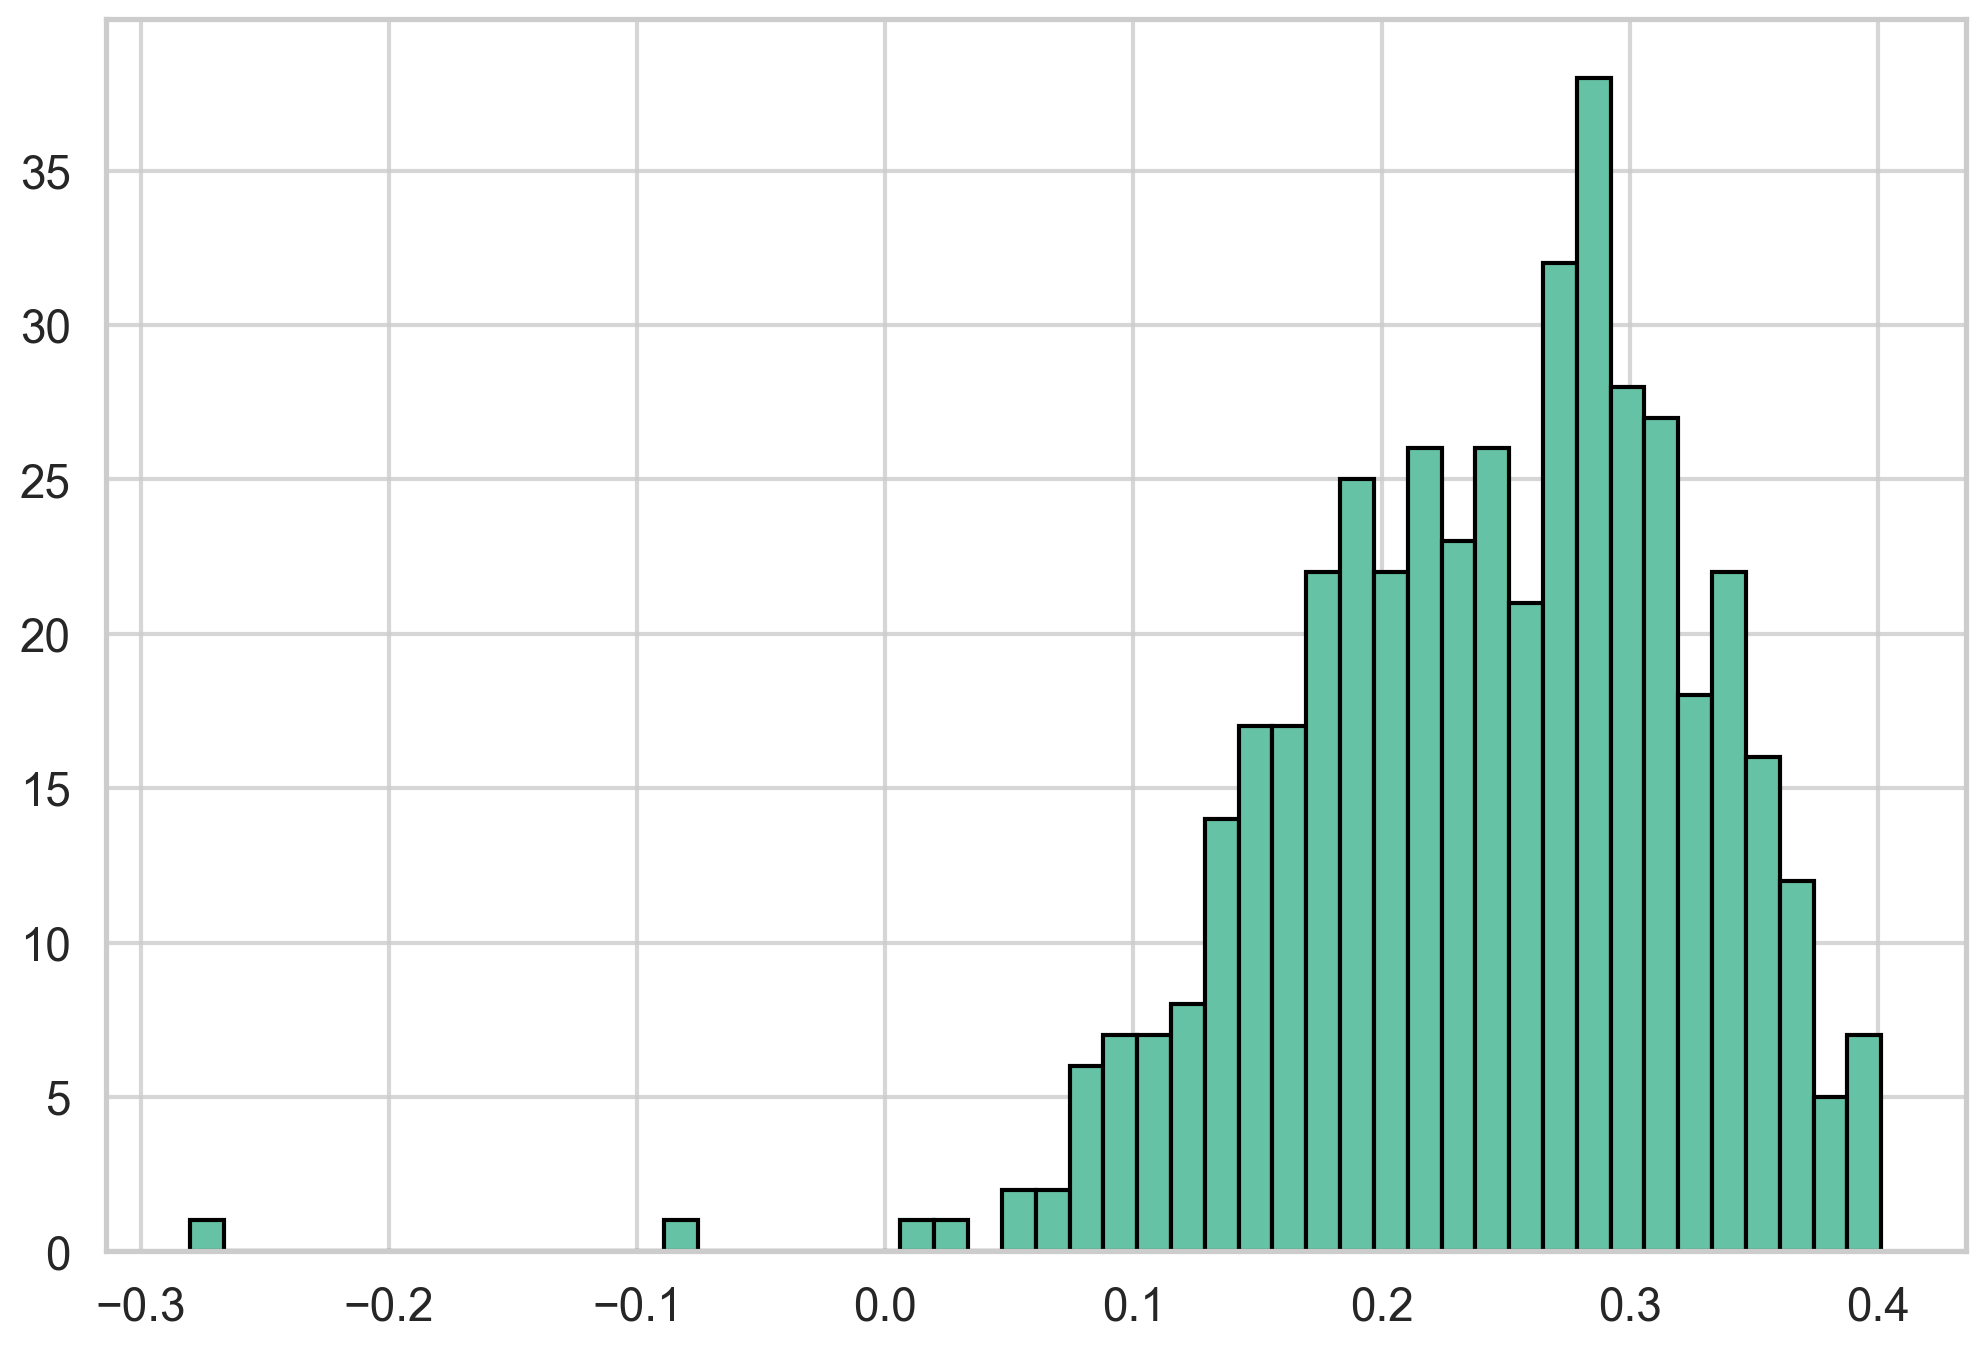

In [ ]:
# stacked_models["MAE_weighted"].hist()
# plt.scatter(y,y_pred)
# stacked_models.sort_values("MAE", ascending=True)
stacked_models["R2"].hist(bins=50, edgecolor="k")

In [ ]:
import numpy as np
import pandas as pd
import nibabel as nb
from nilearn import surface, datasets
from surfplot import Plot
from matplotlib.colors import TwoSlopeNorm  # nice diverging colours
from neuromaps.datasets import fetch_fslr
from brainspace.datasets import load_parcellation
import nibabel as nib


atlas_img = nib.load(nifti_matlab)

# ---------------------------------------------------------------------
# 2.  FETCH A STANDARD SURFACE  (fsaverage5 = 10k vertices per hemi)
# ---------------------------------------------------------------------
surfaces = fetch_fslr()
lh, rh = surfaces["veryinflated"]


# ---------------------------------------------------------------------
# 3.  SAMPLE ATLAS VOXELS → SURFACE  (nearest-neighbour so labels stay int)
# ---------------------------------------------------------------------
# add schaefer parcellation (no color bar needed)
lh_parc, rh_parc = load_parcellation("schaefer")

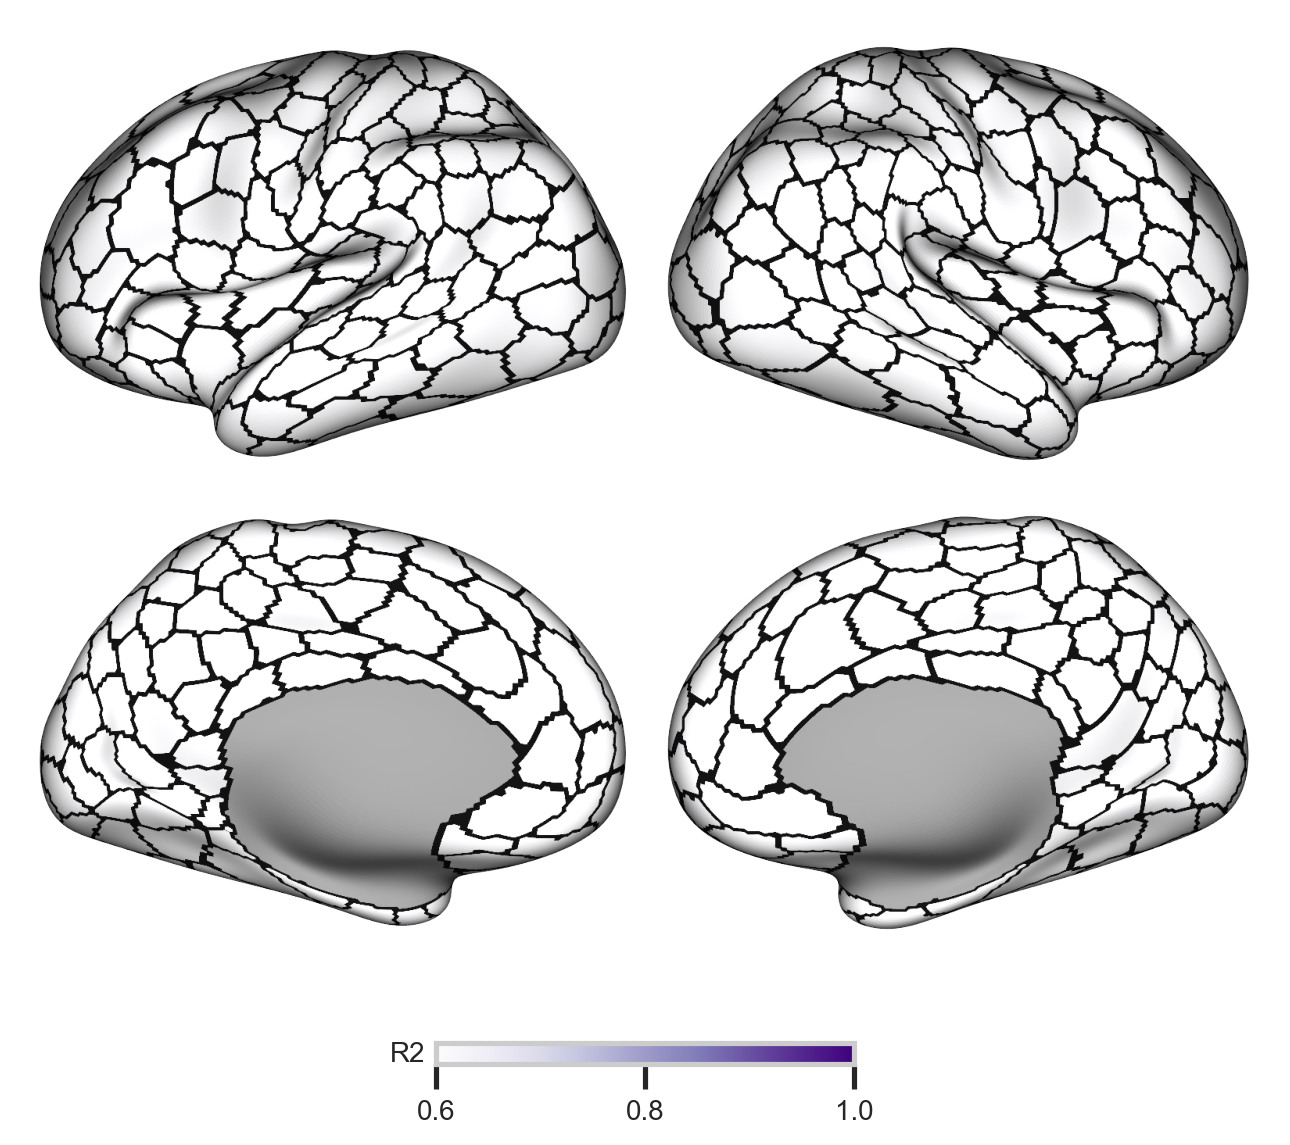

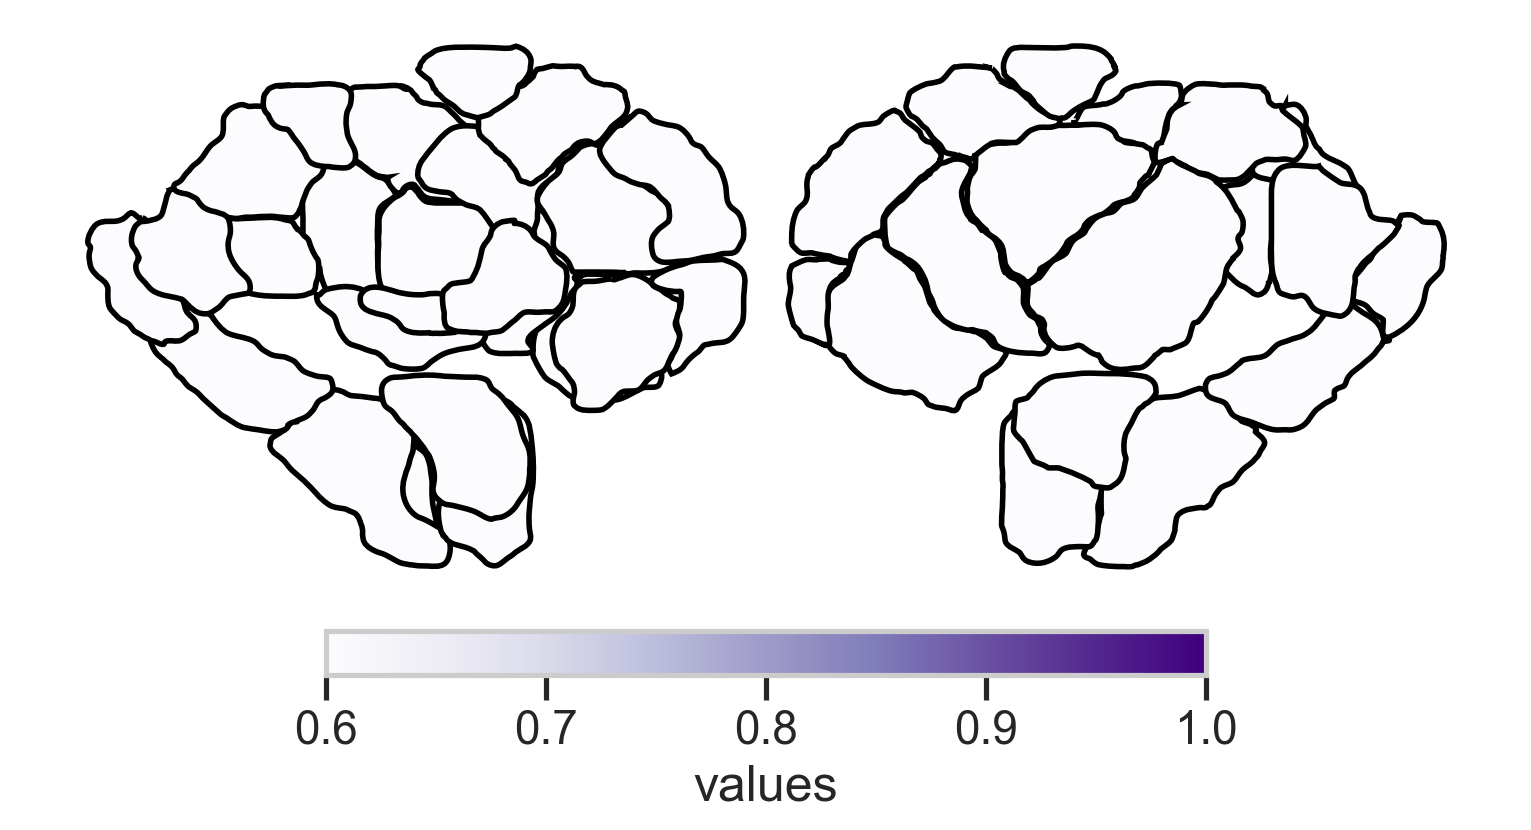

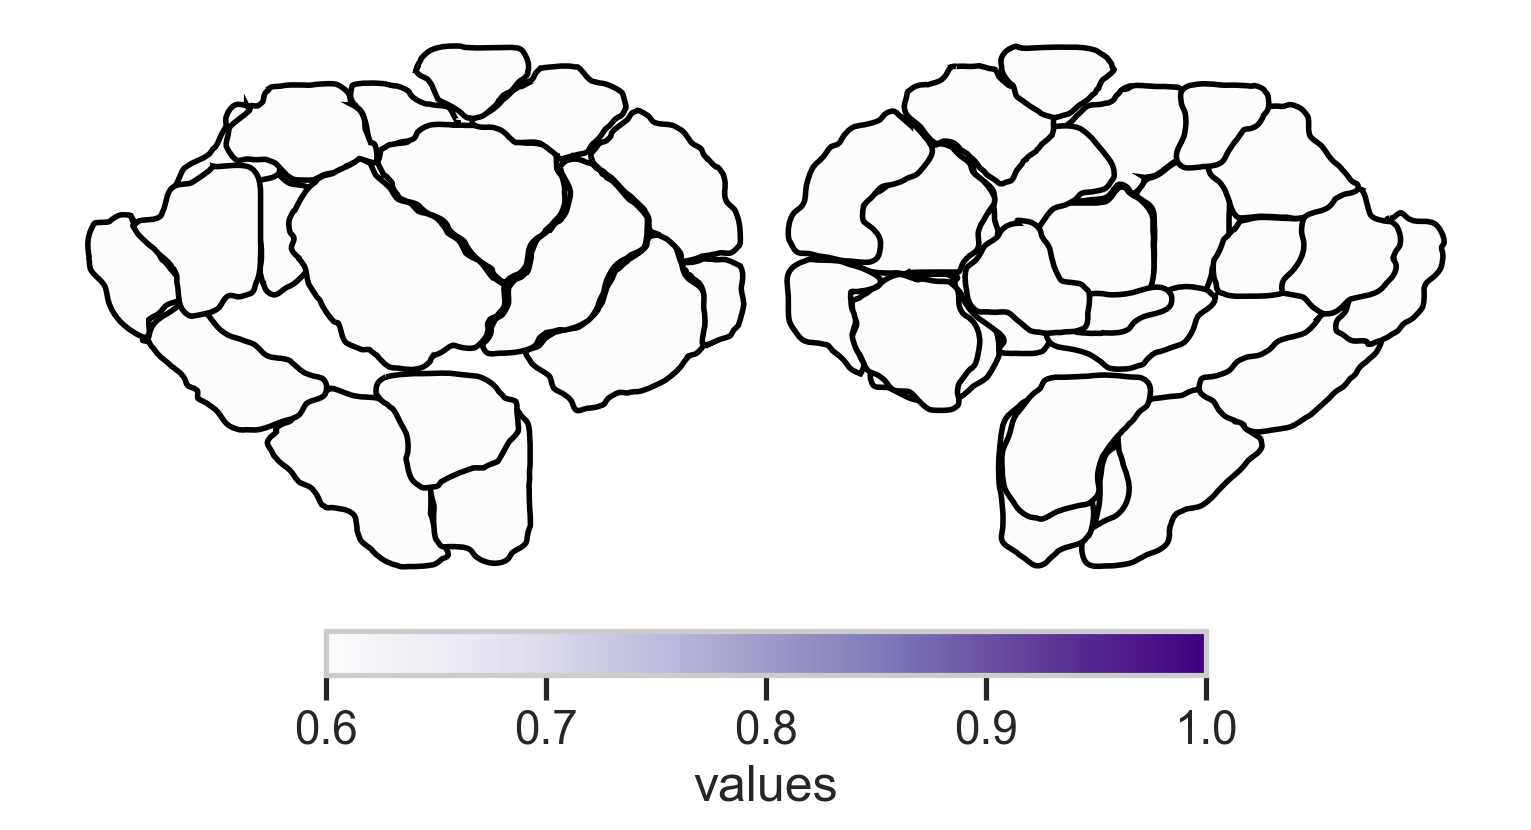

In [ ]:
from subcortex_visualization.plotting import plot_subcortical_data

# ---------------------------------------------------------------------
# 4.  MAP REGION IDs → METRIC VALUES
#     vertices with label 0 (background) → NaN so they render transparent
# ---------------------------------------------------------------------
p_threshold = 0.05
value_threshold = 0

value_map = {}
value_map_subcortex = {"region": [], "value": [], "Hemisphere": []}

vmin = 0.6
vmax = 1
cmap = "Purples"  # cmap for visualization

vis_df = stacked_models.copy()  # Use the stacked_models DataFrame

# vis_df = stats.copy()
# p_column = "p_val"
value_column = "R2"

value_map_lh = {}  # New: separate map for left hemisphere
value_map_rh = {}  # New: separate map for right hemisphere

for i, row in vis_df.iterrows():
    label = row[region_col]
    hemi_row = row["hemisphere"]  # Get hemisphere from your DataFrame row

    # Apply thresholds
    if np.abs(row[value_column]) > value_threshold:
        value = row[value_column]
    else:
        value = np.nan  # Set to NaN if not significant or below value_threshold

    # Populate the correct hemisphere's value_map
    # Assuming your labels are global and you use the 'hemisphere' column to distinguish
    # If your Schaefer labels are already separated by hemi (e.g., 1-200 for LH, 201-400 for RH)
    # then you might only need to check the label range and not the 'hemisphere' column.
    # For Schaefer, the labels usually run 1-N for LH and N+1 - 2N for RH
    if "schaefer" in ATLAS:
        if label > int(ATLAS.split("_")[1]):
            value_map_subcortex["region"].append(label)
            value_map_subcortex["value"].append(value)
            value_map_subcortex["Hemisphere"].append(row["hemisphere"])
        else:
            if hemi_row == "L":
                value_map_lh[label] = value
            elif hemi_row == "R":
                value_map_rh[label] = value
        # Subcortex handling would go here if you were preparing for separate subcortical visualization
        # else: # This implies it's subcortical or other non-surface region
        #     value_map_subcortex["region"].append(label)
        #     value_map_subcortex["value"].append(value)
        #     value_map_subcortex["Hemisphere"].append(row["hemisphere"])

# Vectorize mapping for left and right hemispheres separately
vec_lh = np.vectorize(lambda x: value_map_lh.get(x, np.nan))
data_lh_mapped = vec_lh(lh_parc)  # Apply LH map to LH parcellation
vec_rh = np.vectorize(lambda x: value_map_rh.get(x, np.nan))
data_rh_mapped = vec_rh(rh_parc)  # Apply RH map to RH parcellation


p = Plot(
    lh,
    rh,
    # Unpack the surface dictionary
    # views=["medial", "lateral"],  # Show both medial and lateral for this hemi
    size=(800, 600),  # px; change as needed
    zoom=1.6,
    layout="grid",  # Horizontal layout for side-by-side views
    mirror_views=True,  # Set to False, as we are plotting one hemi at a time
)

# ---- main data layer -------------------------------------------------
# Pass only the data for the current hemisphere
# The dictionary now contains only one key-value pair for the current hemisphere
p.add_layer(
    {"left": data_lh_mapped, "right": data_rh_mapped},
    cmap=cmap,
    # cmap="coolwarm",
    #     # cmap="coolwarm",
    color_range=(vmin, vmax),  # Use symmetric range
    #     # norm=norm,  # Apply the symmetric normalization
    cbar_label=value_column,
    cbar=True,  # Ensure colorbar is shown for each plot if desired, or handle globally
)
# # ---- outline layer ---------------------------------------------------
p.add_layer({"left": lh_parc, "right": rh_parc}, cmap="gray", as_outline=True, cbar=False)

fig = p.build(
    # cbar_kws=dict(location="bottom", decimals=2, shrink=0.6)
)  # Added cbar_kws for better cbar display
# # save figure
# savefig_nice(
#     fig,
#     f"/media/storage/gepner/derivatives/gepner_{col}_cort_t.png",
#     tight=True,
#     dpi=300,
# )


subcort_df = pd.DataFrame(value_map_subcortex)
if "schaefer" in ATLAS:
    subcort_df["region"] = subcort_df["region"] - int(ATLAS.split("_")[1])


for hemi in ["L", "R"]:

    fig = plot_subcortical_data(
        subcort_df,
        atlas="Melbourne_S3",
        show_legend=True,
        hemisphere=hemi,
        cmap=cmap,
        line_color="black",
        line_thickness=2,
        vmin=vmin,
        vmax=vmax,
        show_figure=False,
    )

    # save figure
    # savefig_nice(
    #     fig,

    #     f"/media/storage/gepner/derivatives/subcortical_{col}_{hemi}_t.png",
    #     tight=True,
    #     dpi=300,
    # )
    # savefig_nice(fig, OUTPUT_DIR / f"fig2_subcort_{metric}_{hemi}_{value_column}.png", dpi=400)

In [ ]:
av_subjects = predictions[0]["corrected_residuals"].dropna().index

predictions_df = pd.DataFrame(index=av_subjects, columns=parcels[region_col].unique())
for i, pred_df in predictions.items():
    roi = parcels.loc[i, region_col]
    pred_df = pred_df[pred_df.index.isin(av_subjects)]
    predictions_df[roi] = pred_df["corrected_residuals"]

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer


df = pd.read_csv("~/Projects/plasticityhub/sessions.csv")
df["subject_code"] = (
    df["subject_code"].astype(str).str.replace("-", "").str.replace(" ", "").str.replace("_", "")
)
# df_cov = pd.read_csv("~/Projects/neuroaging/data/external/sessions.csv")
df = df[df["subject_code"].isin(av_subjects)]
df = df.drop_duplicates(subset=["subject_code"]).set_index("subject_code")
# df_cov = pd.read_pickle(f"/media/storage/phd/papers/aging/{ATLAS}/gm_vol.pkl").reset_index(
#     drop=True

# merge with cov
# df_cov = df_cov.merge(cov, left_on="subject_code", right_index=True, how="inner")
df["BMI"] = df["weight"] / ((df["height"] / 100) ** 2)


# exercise_frequency_mapping = {
#     "פעמיים-שלוש בשבוע": 2.5,
#     "1-1": 1.5,
#     "יותר מ-3 פעמים בשבוע": 4,
# }
# df_cov["exercise_frequency"] = df_cov["exercise_frequency"].map(
#     exercise_frequency_mapping
# )
df["number_of_children"] = df["number_of_children"].fillna(0)

education_level_mapping = {
    "elementary school": 1,
    "partial high school": 2,
    "high_school": 3,
    "post-secondary": 4,
    "undergraduate": 5,
    "bachelor's degree": 6,
    "U": np.nan,
    # "other": np.nan,
}
df["education_level"] = df["education_level"].map(education_level_mapping)

for col in ["blood_sugar", "blood_pressure", "thyroids", "lipids"]:
    df[col] = (
        df[col]
        .str.lower()
        .map(
            {
                "high": 1,
                "normal": 0,
                "low": -1,
                "very low": -2,
                "very high": 2,
            }
        )
    )


a = (
    df["nutrition"]
    .str.replace("קטוגני/נמנע מפחמימות", "Ketogenic")
    .str.replace("Free from", "Ketogenic")
    .str.replace(",", " ")
    .str.strip()
    .fillna("Unknown")
)


ml = MultiLabelBinarizer()
nutrition_df = pd.DataFrame(ml.fit_transform(a.str.split()), columns=ml.classes_, index=a.index)
nutrition_df = nutrition_df.rename(columns=lambda x: x.replace(" ", "_").replace("-", "_"))
nutrition_df = nutrition_df.add_prefix("nutrition_")
nutrition_df = nutrition_df.drop(
    columns=["nutrition_Unknown"], errors="ignore"
)  # Drop 'Unknown' if exists
df = df.join(nutrition_df).drop(columns=["nutrition"])

In [ ]:
fs_output_template = (
    "/media/storage/yalab-dev/derivatives/freesurfer/sub-{subj}/stats/aseg_stats.csv"
)
for subject in df.index:
    fs_output = fs_output_template.format(subj=subject)
    if not Path(fs_output).exists():
        print(f"File {fs_output} does not exist, skipping subject {subject}")
        continue
    fs_df = pd.read_csv(fs_output, sep="\t")
    for col in fs_df.columns:
        df.loc[
            subject,
            col.lower()
            .replace("-", "_")
            .replace("3rd", "third")
            .replace("4th", "fourth")
            .replace("5th", "fifth"),
        ] = fs_df.loc[0, col]

In [ ]:
df = df.replace("", pd.NA)  # Handle empty missing
df["lateral_ventricles_mean"] = df.filter(regex="lateral_ventricle").mean(axis=1)

In [ ]:
mask = df["smoking"] == False & df["smoke_frequency_per_day"].isna()
df.loc[mask, "smoke_frequency_per_day"] = 0

mask = df["cannabis"] == False & df["canabis_frequency_per_week"].isna()
df.loc[mask, "canabis_frequency_per_week"] = 0

df.loc[df["psychometric_score"] == 200, "psychometric_score"] = np.nan

In [ ]:
import pandas as pd
from scipy.stats import spearmanr, ttest_ind, f_oneway, pointbiserialr
import statsmodels.api as OLS
from statsmodels.tools.tools import add_constant

features = [
    "psqi",
    "gad7",
    "phq9",
    "swls",
    "pcl5",
    "b5_extraversion",
    "b5_agreeableness",
    "b5_conscientiousness",
    "b5_emotional_stability",
    "b5_openness",
    "brain_health",
    "BMI",
    "weekly_workouts",
    "screen_time",
    "smartphone_usage",
    "home_cooking_times_per_week",
    "has_pet",
    "smoking",
    "cannabis",
    "alcohol",
    "caffeine",
    # "sugar_beverages",
    "water",
    # "nutrition",
    "marital_status",
    "number_of_children",
    "relationship_duration",
    "living_environment",
    "education_level",
    "psychometric_score",
    "lateral_ventricles_mean",
    "age_at_scan",
    "sex",
] + list(nutrition_df.columns)

In [ ]:
fill_to_0 = [
    "weekly_workouts",
    "home_cooking_times_per_week",
    "number_of_children",
    "relationship_duration",
    "smoking",
    "cannabis",
]
for col in fill_to_0:
    df[col] = df[col].fillna(0)

In [ ]:
# find featues with more than 20% missing values
missing_threshold = 0.2
missing_features = df[features].columns[df[features].isnull().mean() > missing_threshold]
print(
    f"Features with more than {missing_threshold*100}% missing values: {missing_features.tolist()}"
)

features = [f for f in features if f not in missing_features]

Features with more than 20.0% missing values: ['gad7', 'phq9', 'swls', 'pcl5', 'screen_time', 'smartphone_usage', 'has_pet', 'education_level', 'psychometric_score']


In [ ]:
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer  # Added for missing values

# Preprocessor
numeric_features = [
    f for f in features if df[f].dtype in ["float64", "int64"]
]  # Continuous/ordinal
categorical_features = [f for f in features if f not in numeric_features]
# Sub-pipelines for imputation + processing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),  # Handle missing numerics
        ("scaler", StandardScaler()),
    ]
)
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),  # Handle missing categoricals/binaries
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        # ('binary_sex', 'passthrough', ['sex_M'])  # Assume sex encoded as sex_M=1 for male; add imputer if missing
    ]
)

X_scaled = preprocessor.fit_transform(df[features])

In [ ]:
# missing_rates_df = df[features].isnull().sum().reset_index()
# missing_rates_df.columns = ['feature', 'missing_rate']
# missing_rates_df.sort_values(by='missing_rate', ascending=False)

In [ ]:
from sklearn.model_selection import GridSearchCV, cross_val_score
import shap

results = parcels.copy()
importances = {}

en_estimator = ElasticNetCV(
    alphas=alphas,
    l1_ratio=[0.1, 0.5, 0.9, 1.0],  # Explore different l1 ratios
    # scoring='neg_mean_absolute_error',
    cv=5,
    random_state=42,
)
estimator = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    # n_jobs=-1
)

for i, row in tqdm(parcels.iterrows(), total=parcels.shape[0], desc="Fitting models"):
    if "HIP" not in row["base_name"]:
        continue
    roi = row[region_col]
    y = predictions_df[roi]  # Target: regional BAG
    grid = GridSearchCV(
        estimator,
        param_grid={
            "n_estimators": [100, 200, 300],
            "max_depth": [5, 10, 15],
            # "min_samples_split": [2, 5, 10],
            # "min_samples_leaf": [1, 2, 4],
        },
        scoring="neg_mean_absolute_error",
        cv=5,
        n_jobs=-1,
    )
    grid.fit(X_scaled, y)
    pipeline = grid.best_estimator_
    for scorer in ["r2", "neg_mean_absolute_error", "neg_root_mean_squared_error"]:
        res = cross_val_score(pipeline, X_scaled, y, cv=5, scoring=scorer)
        results.loc[i, f"{scorer}_mean"] = np.mean(res)
        results.loc[i, f"{scorer}_std"] = np.std(res)
    # Get coefficients (for interpretation; abs value for strength)
    coefs = pipeline.feature_importances_
    feature_names = preprocessor.get_feature_names_out()
    importance_df = pd.DataFrame({"feature": feature_names, "coef": coefs}).sort_values(
        by="coef", key=abs, ascending=False
    )
    importances[i] = importance_df

    # break

Fitting models:  94%|█████████▍| 429/454 [02:48<00:27,  1.09s/it]

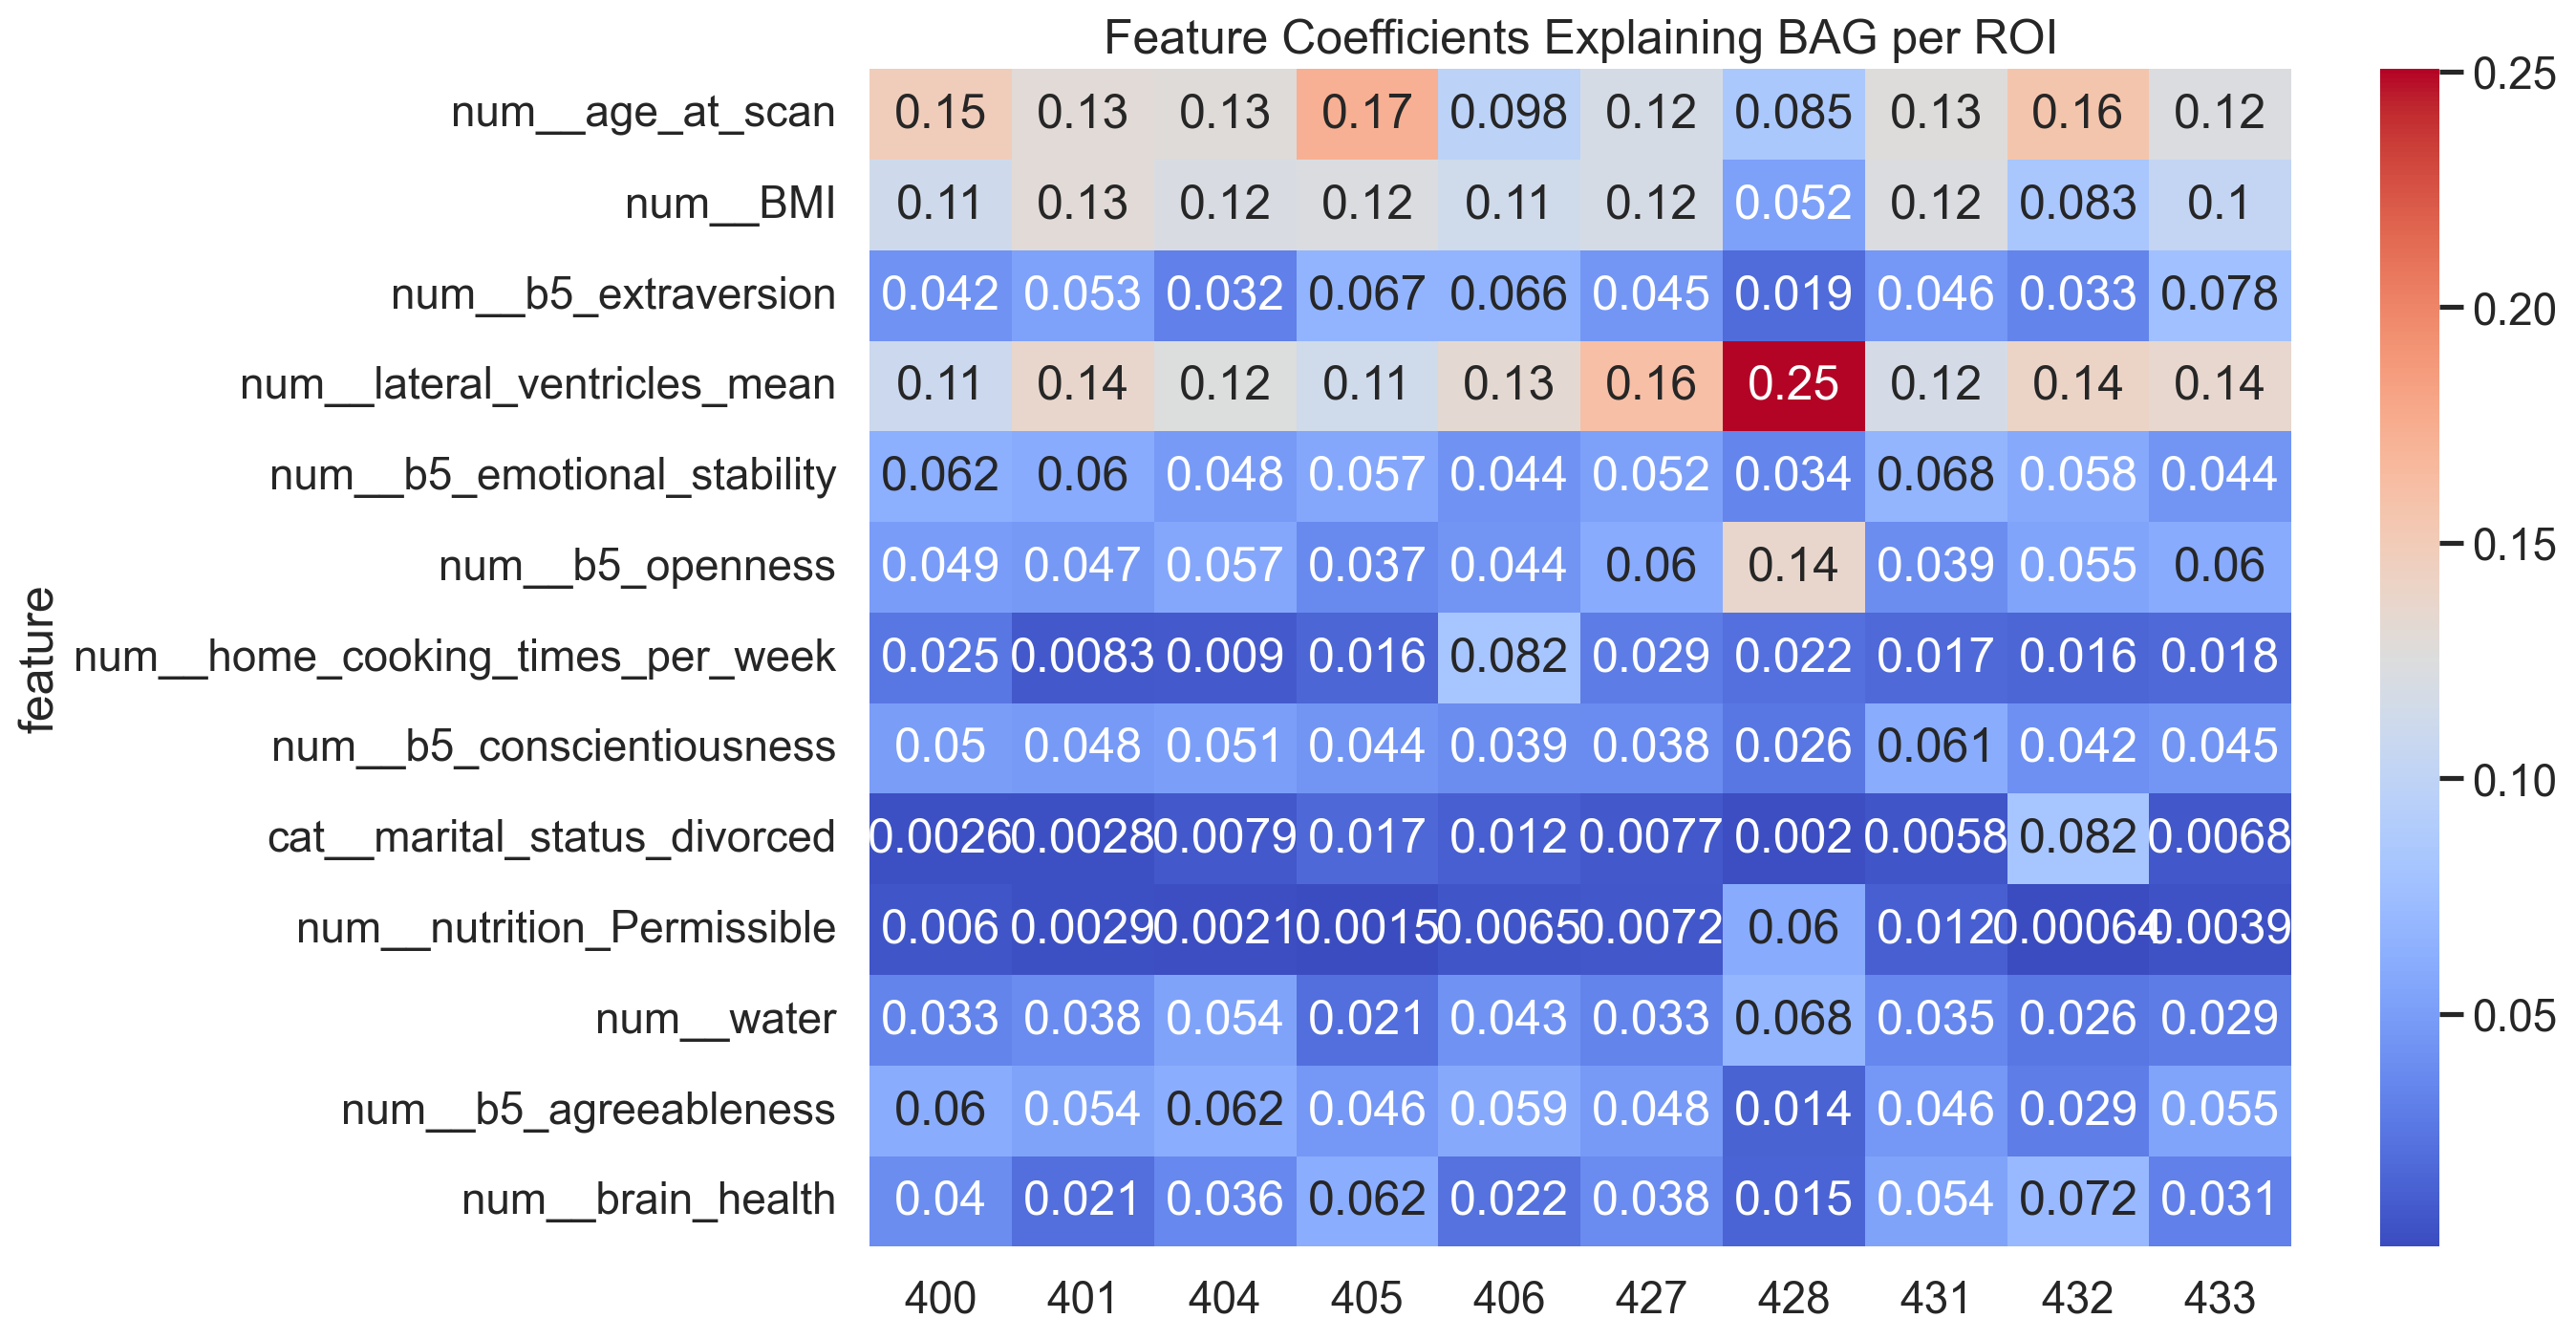

In [ ]:
ind = [400, 401, 404, 405, 406, 427, 428, 431, 432, 433]

top_features = set()
for res in importances.values():
    top_features.update(res["feature"].head(5))
coef_matrix = pd.DataFrame(
    {roi: res.set_index("feature")["coef"] for roi, res in importances.items()}
).reindex(top_features)
sns.heatmap(coef_matrix, annot=True, cmap="coolwarm")
plt.title("Feature Coefficients Explaining BAG per ROI")
plt.show()

In [ ]:
importances

{400:                                           feature      coef
 16                               num__age_at_scan  0.147885
 7                                        num__BMI  0.112010
 15                   num__lateral_ventricles_mean  0.109297
 4                     num__b5_emotional_stability  0.062350
 2                           num__b5_agreeableness  0.060268
 0                                       num__psqi  0.055108
 3                       num__b5_conscientiousness  0.050086
 5                                num__b5_openness  0.048914
 1                            num__b5_extraversion  0.041943
 6                               num__brain_health  0.039645
 10                                   num__alcohol  0.033501
 12                                     num__water  0.033140
 14                     num__relationship_duration  0.031603
 11                                  num__caffeine  0.025475
 9                num__home_cooking_times_per_week  0.025463
 25                

In [ ]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer  # Added for missing values

pls_results = {}
for i, row in tqdm(parcels.iterrows(), total=parcels.shape[0], desc="Fitting PLS models"):
    if "HIP" not in row["base_name"]:
        continue
    y = predictions_df[row[region_col]]
    pls = PLSRegression(n_components=3)  # Tune n_components via CV
    pls.fit(X_scaled, y)
    # Loadings: How features contribute to components explaining BAG
    loadings = pd.DataFrame(
        pls.x_loadings_,
        columns=[f"Component {i+1}" for i in range(3)],
        index=preprocessor.get_feature_names_out(),
    )
    explained_var = pls.score(X_scaled, y)  # R²-like
    pls_results[roi] = {
        "explained_var": explained_var,
        "loadings": loadings.abs().sort_values(by="Component 1", ascending=False),
    }
    break

Fitting PLS models:  88%|████████▊ | 400/454 [00:00<00:00, 20363.91it/s]
